### SPEI

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from climate_indices import indices
from climate_indices.compute import Periodicity
from climate_indices.indices import Distribution
import dask
from dask.distributed import Client, LocalCluster
import os

# ----------------------------
# 1. 首先配置 Dask 并行
# ----------------------------
cluster = LocalCluster(
    n_workers=20,           
    threads_per_worker=1,
    memory_limit="10GB"     
)
client = Client(cluster)

# print(client)
print("Dashboard 地址:", client.dashboard_link)


def spei_1d(precip, pet, scale=3,
            data_start_year=1915,
            calibration_year_initial=1915,
            calibration_year_final=2019):
    """计算一维时间序列的 SPEI"""
    if precip.size < scale or np.all(np.isnan(precip)) or np.all(np.isnan(pet)):
        return np.full(precip.shape, np.nan, dtype=float)


    spei_values = indices.spei(
        precips_mm=precip,
        pet_mm=pet,
        scale=scale,
        distribution=Distribution.gamma,
        periodicity=Periodicity.daily,
        data_start_year=data_start_year,
        calibration_year_initial=calibration_year_initial,
        calibration_year_final=calibration_year_final
    )
    return spei_values



et_his = xr.open_dataset(r"F:\paper4\GWSP3_W5E5\ETRef_daily.nc",chunks={"lat": 30, "lon": 30, "time": -1}).ETRef.astype(np.float32) 

pr_his = xr.open_dataset(r"F:\paper4\GWSP3_W5E5\Precipitation_daily.nc",chunks={"lat": 30, "lon": 30, "time": -1}).Precipitation.astype(np.float32)  


spei_da = xr.apply_ufunc(
    spei_1d,
    pr_his,
    et_his,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
    dask_gufunc_kwargs={"allow_rechunk": True},
    kwargs={
        "scale": 60,
        "data_start_year": 1915,
        "calibration_year_initial": 1915,
        "calibration_year_final": 2019
    }
)


# ----------------------------
# 5. 保存结果（推荐：边算边写）
# ----------------------------
output_file = r"E:\smq\spei\SPEI_daily1.nc"
encoding = {"spei": {"zlib": True, "complevel": 4, "dtype": "float32"}}

# 如果文件已存在，先删除
if os.path.exists(output_file):
    os.remove(output_file)

# 使用 h5netcdf 引擎，支持 Dask 并行写
delayed_obj = spei_ds.to_netcdf(
    output_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=False  # 边算边写，不一次性塞进内存
)

import dask
dask.compute(delayed_obj)  # 触发计算和写入

print(f"[Success] 文件已写入: {output_file}")


In [ ]:

import xarray as xr
import matplotlib.pyplot as plt

# ======================
# 1. 读取数据
# ======================
fp = r"E:\smq\spei\SPEI_daily1.nc"
spei_daily = xr.open_dataset(fp, engine="h5netcdf")['spei']

# ======================
# 2. 按年聚合（平均）
# ======================
spei_annual = spei_daily.resample(time="1Y").mean(dim="time")
spei_annual_mean = spei_annual.mean(dim=["lat", "lon"])

# ======================
# 3. 保存年聚合结果为 NetCDF
# ======================
output_file = r"E:\smq\spei\SPEI_annual_mean.nc"

# 保险起见，如已有旧文件则先删除
if os.path.exists(output_file):
    os.remove(output_file)

encoding = {"spei": {"zlib": True, "complevel": 4, "dtype": "float32"}}

# 创建Dataset并保存
spei_annual_ds = xr.Dataset({"spei": spei_annual})
spei_annual_ds.to_netcdf(output_file, engine="h5netcdf", encoding=encoding)

print(f"[✅ 成功] 年聚合 SPEI 文件已保存至：{output_file}")


HW

In [ ]:
import xarray as xr
import numpy as np
from dask.distributed import Client
import os

# ======================
# 1. 启动 Dask
# ======================
client = Client(n_workers=10, threads_per_worker=2, memory_limit="100GB")
print("Dask dashboard:", client.dashboard_link)

# ======================
# 2. 参数设置
# ======================
min_days = 3
start_date, end_date = "1920-01-01", "2019-12-31"

# ======================
# 3. 读取数据
# ======================
tas95 = xr.open_dataset(r"E:\smq\tas95_1981_2010.nc",
                        chunks={"lat": 50, "lon": 50})["tas95"] - 273.15

tasmax = xr.open_dataset(r"E:\smq\Tmax\TMax_daily.nc",
                         engine="h5netcdf").sel(time=slice(start_date, end_date)) \
                         .chunk({"time": -1, "lat": 50, "lon": 50})["TMax"]

# ======================
# 4. 热浪检测（逐像元函数）
# ======================
def detect_events_1d(flag, min_days=3):
    mask = np.zeros_like(flag, dtype=bool)
    count = 0
    for i in range(len(flag)):
        if flag[i]:
            count += 1
        else:
            if count >= min_days:
                mask[i-count:i] = True
            count = 0
    if count >= min_days:
        mask[len(flag)-count:] = True
    return mask

# 热浪定义
hot_flag = tasmax > tas95

# 热浪mask（True 表示处于热浪）
hw_mask = xr.apply_ufunc(
    detect_events_1d,
    hot_flag,
    input_core_dims=[["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[bool],
    kwargs={"min_days": min_days},
)

# ======================
# 5. 按年计算热浪天数占比
# ======================
# 每年热浪天数
hw_days = hw_mask.resample(time="1Y").sum(dim="time")

# 每年总天数（自动考虑闰年）
total_days = hw_mask["time"].resample(time="1Y").count()

# 每年占比（百分比）
hw_ratio = (hw_days / total_days) * 100
hw_ratio = hw_ratio.compute()
hw_ratio.name = "hw_days_ratio"
hw_ratio.attrs["units"] = "%"
hw_ratio.attrs["description"] = "每年热浪天数占全年天数比例（%）"

# ======================
# 6. 保存结果
# ======================
ds_out = hw_ratio.to_dataset(name="hw_days_ratio")

out_fp = r"D:\smq\paper2\data\hw_days_ratio_annual.nc"
if os.path.exists(out_fp):
    os.remove(out_fp)

encoding = {"hw_days_ratio": {"zlib": True, "complevel": 4, "dtype": "float32"}}
ds_out.to_netcdf(out_fp, engine="h5netcdf", encoding=encoding)

print(f"[✅ 成功] 文件已保存: {out_fp}")

# ======================
# 7. 关闭 Dask
# ======================
client.close()


### CDHW

In [ ]:
import xarray as xr
import numpy as np
from dask.distributed import Client

# ======================
# 配置 Dask
# ======================
client = Client(n_workers=10, threads_per_worker=2, memory_limit="100GB")
print("Dask dashboard:", client.dashboard_link)

# ======================
# 参数
# ======================
min_days = 3
spei_thresh = -1
start_date, end_date = "1920-01-01", "2019-12-31"

# ======================
# 打开数据
# ======================
tas95 = xr.open_dataset(r"E:\smq\tas95_1981_2010.nc",
                        chunks={"lat": 50, "lon": 50})["tas95"] - 273.15

tasmax = xr.open_dataset(r"E:\smq\Tmax\TMax_daily.nc",
                         engine="h5netcdf").sel(time=slice(start_date, end_date)) \
                         .chunk({"time": -1, "lat": 50, "lon": 50})["TMax"]

spei = xr.open_dataset(r"E:\smq\spei\SPEI_daily1.nc",
                       engine="h5netcdf").sel(time=slice(start_date, end_date)) \
                       .chunk({"time": -1, "lat": 50, "lon": 50})["spei"]

# ======================
# Step1: 干旱和热浪 flag
# ======================
drought_flag = spei < spei_thresh
hot_flag = tasmax > tas95

# ======================
# Step2: 定义逐像元函数，找到连续 >= min_days 的事件
# ======================
def detect_events_1d(flag, min_days=3):
    mask = np.zeros_like(flag, dtype=bool)
    count = 0
    for i in range(len(flag)):
        if flag[i]:
            count += 1
        else:
            if count >= min_days:
                mask[i-count:i] = True
            count = 0
    # 结尾再检查一次
    if count >= min_days:
        mask[len(flag)-count:] = True
    return mask

hw_mask = xr.apply_ufunc(
    detect_events_1d,
    hot_flag,
    input_core_dims=[["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[bool],
    kwargs={"min_days": min_days},
)

# ======================
# Step3: CDHW = 热浪日 & 干旱日
# ======================
cdhw_mask = hw_mask & drought_flag

# ======================
# Step4: baseline = 非干旱 & 非热浪
# ======================
baseline_mask = (~drought_flag) & (~hw_mask)

# ======================
# Step5: 保存结果
# ======================
ds_out = xr.Dataset(
    {
        "drought_mask": drought_flag.astype(np.int8),
        "hw_mask": hw_mask.astype(np.int8),
        "cdhw_mask": cdhw_mask.astype(np.int8),
        "baseline_mask": baseline_mask.astype(np.int8),
    }
)

# 压缩设置
comp = dict(zlib=True, complevel=4)
encoding = {var: comp for var in ds_out.data_vars}

# 保存
out_fp = r"D:\smq\paper2\data\masks_cdhw_hw_di.nc"
ds_out.to_netcdf(out_fp, encoding=encoding)
print("保存完成:", out_fp)



### result1

### Frequency

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from dask.distributed import Client, LocalCluster
import os
import dask  # 提前导入dask，避免后续计算时导入延迟

# ======================
# 配置 Dask
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="100GB"
)
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ======================
# 读掩膜数据（修复分块警告）
# ======================
mask_fp = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
ds_mask = xr.open_dataset(
    mask_fp,
    engine="h5netcdf"
).chunk({"time": -1, "lat": 50, "lon": 50})
cdhw_mask = ds_mask["cdhw_mask"]

# ======================
# 每个格点的事件→年度次数函数
# ======================
def process_point(mask_1d, time_vals):
    mask_np = mask_1d.astype(int)

    # Step1: 标记事件ID
    eid = 0
    in_event = False
    event_id = np.zeros_like(mask_np, dtype=int)
    for i, val in enumerate(mask_np):
        if val == 1 and not in_event:
            eid += 1
            in_event = True
        elif val == 0:
            in_event = False
        if in_event:
            event_id[i] = eid

    # Step2: 按年份统计事件数（取每个事件的开始日所在年份）
    years, counts = [], []
    if eid > 0:
        for e in np.unique(event_id):
            if e == 0:
                continue
            idx = np.where(event_id == e)[0]
            year = pd.to_datetime(time_vals[idx[0]]).year
            years.append(year)

    # Step3: 年度对齐
    years_all = np.arange(
        pd.to_datetime(time_vals[0]).year,
        pd.to_datetime(time_vals[-1]).year + 1
    )
    c = np.zeros(years_all.shape, dtype=np.float32)
    if len(years) > 0:
        df = pd.Series(years).value_counts()
        for y, n in df.items():
            c[np.searchsorted(years_all, y)] = n

    return c  # 输出 shape=(nyears,)

# ======================
# 计算完整年份范围（用于输出维度）
# ======================
years_all = np.arange(
    int(cdhw_mask.time.dt.year.min()),
    int(cdhw_mask.time.dt.year.max()) + 1
)

# ======================
# 并行调用函数
# ======================
annual_count = xr.apply_ufunc(
    process_point,
    cdhw_mask,
    cdhw_mask["time"],
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["year"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float32],
    dask_gufunc_kwargs={"output_sizes": {"year": len(years_all)}},
)

annual_count = annual_count.assign_coords(year=years_all)
annual_count.name = "annual_event_count"

# ======================
# 创建Dataset
# ======================
ds_out = xr.Dataset(
    data_vars={"annual_event_count": annual_count},
    coords={
        "year": years_all,
        "lat": cdhw_mask.lat,
        "lon": cdhw_mask.lon
    }
)

# ======================
# 保存结果
# ======================
output_file = r"D:\smq\paper2\data\cdhw\cdhw_event_count_yearly.nc"
encoding = {
    "annual_event_count": {"zlib": True, "complevel": 4, "dtype": "float32"}
}

if os.path.exists(output_file):
    os.remove(output_file)

print("保存结果...")
delayed = ds_out.to_netcdf(
    output_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=False
)
dask.compute(delayed)

print(f"[Success] 文件已写入: {output_file}")
client.close()


### Duration

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
from dask.distributed import Client, LocalCluster
import dask
import os

# ======================
# 1. 启动 Dask 并行环境
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="100GB"
)
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ======================
# 2. 读取掩膜数据（事件标记）
# ======================
mask_fp = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
ds_mask = xr.open_dataset(mask_fp, engine="h5netcdf").chunk({"time": -1, "lat": 20, "lon": 20})
cdhw_mask = ds_mask["cdhw_mask"]  # 值为 0/1，表示是否处于CDHW事件中

# ======================
# 3. 定义逐格点函数
# ======================
def calc_annual_duration(mask_1d, time_vals):
    """
    计算每个格点每年的平均事件持续时间（天）
    """
    times = pd.to_datetime(time_vals)
    years_all = np.arange(times[0].year, times[-1].year + 1)
    c = np.zeros(len(years_all), dtype=np.float32)

    in_event = False
    event_id = np.zeros(len(mask_1d), dtype=int)
    eid = 0

    for i, val in enumerate(mask_1d):
        if val > 0 and not in_event:
            eid += 1
            in_event = True
        elif val == 0:
            in_event = False
        if in_event:
            event_id[i] = eid

    # 收集每年事件持续时间
    yearly_durations = {year: [] for year in years_all}
    for e in np.unique(event_id):
        if e == 0:
            continue
        idx = np.where(event_id == e)[0]
        start_idx = idx[0]
        dur = len(idx)
        year = times[start_idx].year
        yearly_durations[year].append(dur)

    # 按年平均
    for i, y in enumerate(years_all):
        durs = yearly_durations[y]
        c[i] = np.mean(durs) if len(durs) > 0 else 0.0

    return c

# ======================
# 4. 年份范围
# ======================
years_all = np.arange(
    int(cdhw_mask.time.dt.year.min()),
    int(cdhw_mask.time.dt.year.max()) + 1
)

# ======================
# 5. 并行 apply_ufunc
# ======================
annual_duration = xr.apply_ufunc(
    calc_annual_duration,
    cdhw_mask,               # ✅ 正确输入：事件mask
    cdhw_mask["time"],
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["year"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float32],
    dask_gufunc_kwargs={"output_sizes": {"year": len(years_all)}},
)

annual_duration = annual_duration.assign_coords(year=years_all)
annual_duration.name = "annual_event_duration"

# ======================
# 6. 输出保存
# ======================
ds_out = xr.Dataset(
    {"annual_event_duration": annual_duration},
    coords={"year": years_all, "lat": cdhw_mask.lat, "lon": cdhw_mask.lon}
)

output_file = r"D:\smq\paper2\data\cdhw\cdhw_yearly_event_duration.nc"
encoding = {
    "annual_event_duration": {"zlib": True, "complevel": 4, "dtype": "float32"}
}

if os.path.exists(output_file):
    os.remove(output_file)

print("保存结果中...")
delayed = ds_out.to_netcdf(
    output_file, engine="h5netcdf", encoding=encoding, compute=False
)
dask.compute(delayed)

print(f"[✅ 成功] 文件已写入: {output_file}")
client.close()


C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 54761 instead
  warnings.warn(
C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.08s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


Dashboard 地址: http://127.0.0.1:54761/status
保存结果中...
[✅ 成功] 文件已写入: D:\smq\paper2\data\cdhw\cdhw_yearly_event_duration2.nc


### Intensity

daily

In [ ]:
import xarray as xr
import numpy as np
from dask.distributed import Client, LocalCluster
import dask
import os

# ======================
# 配置 Dask
# ======================
cluster = LocalCluster(
    n_workers=10,           
    threads_per_worker=1,
    memory_limit="100GB"     
)
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ======================
# 参数
# ======================
start_date, end_date = "1920-01-01", "2019-12-31"

# ======================
# 打开数据
# ======================
tas25 = xr.open_dataset(r"D:\smq\paper2\data\tas25_1981_2010.nc")["tas25"] - 273.15
tas75 = xr.open_dataset(r"D:\smq\paper2\data\tas75_1981_2010.nc")["tas75"] - 273.15
tas95 = xr.open_dataset(r"E:\smq\tas95_1981_2010.nc")["tas95"] - 273.15

tasmax = xr.open_dataset(
    r"E:\smq\Tmax\TMax_daily.nc", engine="h5netcdf"
).sel(time=slice(start_date, end_date)).chunk({"time": -1, "lat": 50, "lon": 50})["TMax"]

spei = xr.open_dataset(
    r"E:\smq\spei\SPEI_daily1.nc", engine="h5netcdf"
).sel(time=slice(start_date, end_date)).chunk({"time": -1, "lat": 50, "lon": 50})["spei"]

# ✅ 直接读取现成的 CDHW 掩膜
cdhw_mask = xr.open_dataset(
    r"D:\smq\paper2\data\masks_cdhw_hw_di.nc", engine="h5netcdf"
)["cdhw_mask"].sel(time=slice(start_date, end_date)).chunk({"time": -1, "lat": 50, "lon": 50})

# ======================
# Step: 严重程度（逐日）
# ======================
daily_severity = xr.where(
    cdhw_mask,  # 直接用已有掩膜
    np.abs(spei) * (tasmax - tas25) / (tas75 - tas25),
    0
)

# ======================
# Step: 保存结果
# ======================
ds_out = xr.Dataset({"daily_severity": daily_severity})

output_file = r"D:\smq\paper2\data\cdhw_daily_severity.nc"
encoding = {"daily_severity": {"zlib": True, "complevel": 4, "dtype": "float32"}}

if os.path.exists(output_file):
    os.remove(output_file)

delayed_obj = ds_out.to_netcdf(
    output_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=False
)

dask.compute(delayed_obj)
print(f"[Success] 文件已写入: {output_file}")


event.sum/year

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from dask.distributed import Client, LocalCluster
import os
import dask  # 提前导入dask，避免后续计算时导入延迟

# ======================
# 配置 Dask
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="100GB"
)
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ======================
# 读数据（修复分块警告）
# ======================
mask_fp = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
ds_mask = xr.open_dataset(
    mask_fp,
    engine="h5netcdf"
).chunk({"time": -1, "lat": 20, "lon": 20})
cdhw_mask = ds_mask["cdhw_mask"]

severity_fp = r"D:\smq\paper2\data\cdhw\cdhw_severity_daily.nc"
ds_sev = xr.open_dataset(
    severity_fp,
    engine="h5netcdf"
).chunk({"time": -1, "lat": 20, "lon": 20})
daily_severity = ds_sev["daily_severity"]

# ======================
# 每个格点的事件→年度强度函数
# ======================
import numpy as np
import pandas as pd
import xarray as xr

def process_point_intensity(mask_1d, time_vals):
    """
    计算每个事件的平均强度，并按年份聚合（取每年所有事件平均强度的平均值）

    Parameters:
        mask_1d (np.ndarray): 一维数组，每日强度值（可以是 float）
        time_vals: 时间戳数组，对应 mask_1d 的时间维度

    Returns:
        c (np.ndarray): shape=(n_years,), 每年对应的事件平均强度的平均值
    """
    # 转换时间为 pandas DatetimeIndex
    times = pd.to_datetime(time_vals)

    # 定义年份范围
    years_all = np.arange(times[0].year, times[-1].year + 1)
    c = np.zeros(len(years_all), dtype=np.float32)  # 存储每年的结果

    # Step1: 提取事件（连续非零天为一个事件）
    in_event = False
    event_id = np.zeros(len(mask_1d), dtype=int)
    eid = 0

    for i, val in enumerate(mask_1d):
        if val > 0 and not in_event:
            eid += 1
            in_event = True
        elif val == 0:
            in_event = False
        if in_event:
            event_id[i] = eid

    # Step2: 遍历每个事件，计算其平均强度，并记录起始年份
    yearly_intensities = {year: [] for year in years_all}  # 每年收集事件的平均强度

    for e in np.unique(event_id):
        if e == 0:
            continue  # 跳过无事件区域

        indices = np.where(event_id == e)[0]
        start_idx = indices[0]
        event_values = mask_1d[indices]

        avg_intensity = np.sum(event_values)  # 该事件的平均强度
        year = times[start_idx].year

        if year in yearly_intensities:
            yearly_intensities[year].append(avg_intensity)

    # Step3: 对每一年，取该年所有事件平均强度的平均值
    for i, year in enumerate(years_all):
        intensities = yearly_intensities[year]
        if len(intensities) > 0:
            c[i] = np.mean(intensities)  # 可改为 np.sum 如果需要总和
        else:
            c[i] = 0.0  # 无事件则为0

    return c  # shape=(nyears,)
# ======================
# 计算完整年份范围（用于输出维度）
# ======================
years_all = np.arange(
    int(cdhw_mask.time.dt.year.min()),
    int(cdhw_mask.time.dt.year.max()) + 1
)

# ======================
# 并行调用函数
# ======================
annual_strength = xr.apply_ufunc(
    process_point_intensity,
    # cdhw_mask,
    daily_severity,
    cdhw_mask["time"],
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["year"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float32],
    dask_gufunc_kwargs={"output_sizes": {"year": len(years_all)}},
)

annual_strength = annual_strength.assign_coords(year=years_all)
annual_strength.name = "annual_event_severity"

# ======================
# 创建Dataset
# ======================
ds_out = xr.Dataset(
    data_vars={"annual_event_severity": annual_strength},
    coords={
        "year": years_all,
        "lat": cdhw_mask.lat,
        "lon": cdhw_mask.lon
    }
)

# ======================
# 保存结果
# ======================
output_file = r"D:\smq\paper2\data\cdhw\cdhw_yearly_event_severity.nc"
encoding = {
    "annual_event_severity": {"zlib": True, "complevel": 4, "dtype": "float32"}
}

if os.path.exists(output_file):
    os.remove(output_file)

print("保存结果...")
delayed = ds_out.to_netcdf(
    output_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=False
)
dask.compute(delayed)

print(f"[Success] 文件已写入: {output_file}")
client.close()


event.mean/year

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
from dask.distributed import Client, LocalCluster
import os
import dask  # 提前导入dask，避免后续计算时导入延迟

# ======================
# 配置 Dask
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="100GB"
)
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ======================
# 读数据（修复分块警告）
# ======================
mask_fp = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
ds_mask = xr.open_dataset(
    mask_fp,
    engine="h5netcdf"
).chunk({"time": -1, "lat": 20, "lon": 20})
cdhw_mask = ds_mask["cdhw_mask"]

severity_fp = r"D:\smq\paper2\data\cdhw\cdhw_severity_daily.nc"
ds_sev = xr.open_dataset(
    severity_fp,
    engine="h5netcdf"
).chunk({"time": -1, "lat": 20, "lon": 20})
daily_severity = ds_sev["daily_severity"]

# ======================
# 每个格点的事件→年度强度函数
# ======================
import numpy as np
import pandas as pd
import xarray as xr

def process_point_intensity(mask_1d, time_vals):

    # 转换时间为 pandas DatetimeIndex
    times = pd.to_datetime(time_vals)

    # 定义年份范围
    years_all = np.arange(times[0].year, times[-1].year + 1)
    c = np.zeros(len(years_all), dtype=np.float32)  # 存储每年的结果

    # Step1: 提取事件（连续非零天为一个事件）
    in_event = False
    event_id = np.zeros(len(mask_1d), dtype=int)
    eid = 0

    for i, val in enumerate(mask_1d):
        if val > 0 and not in_event:
            eid += 1
            in_event = True
        elif val == 0:
            in_event = False
        if in_event:
            event_id[i] = eid

    # Step2: 遍历每个事件，计算其平均强度，并记录起始年份
    yearly_intensities = {year: [] for year in years_all}  # 每年收集事件的平均强度

    for e in np.unique(event_id):
        if e == 0:
            continue  # 跳过无事件区域

        indices = np.where(event_id == e)[0]
        start_idx = indices[0]
        event_values = mask_1d[indices]

        avg_intensity = np.mean(event_values)  # 该事件的平均强度
        year = times[start_idx].year

        if year in yearly_intensities:
            yearly_intensities[year].append(avg_intensity)

    # Step3: 对每一年，取该年所有事件平均强度的平均值
    for i, year in enumerate(years_all):
        intensities = yearly_intensities[year]
        if len(intensities) > 0:
            c[i] = np.mean(intensities)  # 可改为 np.sum 如果需要总和
        else:
            c[i] = 0.0  # 无事件则为0

    return c  # shape=(nyears,)
# ======================
# 计算完整年份范围（用于输出维度）
# ======================
years_all = np.arange(
    int(cdhw_mask.time.dt.year.min()),
    int(cdhw_mask.time.dt.year.max()) + 1
)

# ======================
# 并行调用函数
# ======================
annual_strength = xr.apply_ufunc(
    process_point_intensity,
    # cdhw_mask,
    daily_severity,
    cdhw_mask["time"],
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["year"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float32],
    dask_gufunc_kwargs={"output_sizes": {"year": len(years_all)}},
)

annual_strength = annual_strength.assign_coords(year=years_all)
annual_strength.name = "annual_severity"

# ======================
# 创建Dataset
# ======================
ds_out = xr.Dataset(
    data_vars={"annual_severity": annual_strength},
    coords={
        "year": years_all,
        "lat": cdhw_mask.lat,
        "lon": cdhw_mask.lon
    }
)

# ======================
# 保存结果
# ======================
output_file = r"D:\smq\paper2\data\cdhw\cdhw_meanevent_yearly_severity.nc"
encoding = {
    "annual_severity": {"zlib": True, "complevel": 4, "dtype": "float32"}
}

if os.path.exists(output_file):
    os.remove(output_file)

print("保存结果...")
delayed = ds_out.to_netcdf(
    output_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=False
)
dask.compute(delayed)

print(f"[Success] 文件已写入: {output_file}")
client.close()


Fr/Dur

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy import stats
import statsmodels.api as sm

# ======================
# 1. 文件路径
# ======================
fp_y  = r"D:\smq\paper2\data\cdhw\cdhw_meanevent_yearly_severity.nc"
fp_x1 = r"D:\smq\paper2\data\cdhw\cdhw_event_count_yearly.nc"
fp_x2 = r"D:\smq\paper2\data\cdhw\cdhw_yearly_event_duration.nc"

# ======================
# 2. 读取数据
# ======================
y  = xr.open_dataset(fp_y,  engine="h5netcdf")["annual_severity"]
x1 = xr.open_dataset(fp_x1, engine="h5netcdf")["annual_event_count"]
x2 = xr.open_dataset(fp_x2, engine="h5netcdf")["annual_event_duration"]

# 统一时间维度
years = y["year"].values
x1 = x1.sel(year=years)
x2 = x2.sel(year=years)

# ======================
# ✅ 截取指定时间段（例如 1981–2010）
# ======================
start_year, end_year = 1920, 1980
y  = y.sel(year=slice(start_year, end_year))
x1 = x1.sel(year=slice(start_year, end_year))
x2 = x2.sel(year=slice(start_year, end_year))

print(f"已截取年份范围: {y.year.values[0]}–{y.year.values[-1]}")

# ======================
# 3. 定义逐格点多元回归函数
# ======================

def regress_pixel(y_arr, x1_arr, x2_arr):
    mask = np.isfinite(y_arr) & np.isfinite(x1_arr) & np.isfinite(x2_arr)
    if np.sum(mask) < 10:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    y_masked = y_arr[mask]
    x1_masked = x1_arr[mask]
    x2_masked = x2_arr[mask]

    if np.std(y_masked) == 0 or np.std(x1_masked) == 0 or np.std(x2_masked) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    # 标准化
    scaler = StandardScaler()
    X = np.stack([x1_masked, x2_masked], axis=1)
    X_scaled = scaler.fit_transform(X)
    y_scaled = (y_masked - np.mean(y_masked)) / np.std(y_masked)

    # 使用 statsmodels 回归以获得 p 值
    X_scaled = sm.add_constant(X_scaled)  # 添加常数项
    try:
        model = sm.OLS(y_scaled, X_scaled).fit()
    except Exception:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    a, b = model.params[1], model.params[2]
    p_a, p_b = model.pvalues[1], model.pvalues[2]
    r2 = model.rsquared

    return a, b, r2, p_a, p_b
    
# ======================
# 4. 逐格点回归
# ======================
lat = y.lat.values
lon = y.lon.values

coef_a = np.full((len(lat), len(lon)), np.nan)
coef_b = np.full((len(lat), len(lon)), np.nan)
r2_map = np.full((len(lat), len(lon)), np.nan)
p_a_map = np.full((len(lat), len(lon)), np.nan)
p_b_map = np.full((len(lat), len(lon)), np.nan)

for i in tqdm(range(len(lat)), desc="Latitude Loop"):
    for j in range(len(lon)):
        y_arr  = y[i, j, :].values
        x1_arr = x1[i, j, :].values
        x2_arr = x2[i, j, :].values
        a, b, r2, p_a, p_b = regress_pixel(y_arr, x1_arr, x2_arr)
        coef_a[i, j] = a
        coef_b[i, j] = b
        r2_map[i, j] = r2
        p_a_map[i, j] = p_a
        p_b_map[i, j] = p_b

# ======================
# 5. 保存结果为 xarray
# ======================
ds_out = xr.Dataset(
    {
        "coef_freq": (("lat", "lon"), coef_a),
        "coef_dur":  (("lat", "lon"), coef_b),
        "r2":        (("lat", "lon"), r2_map),
        "p_freq":    (("lat", "lon"), p_a_map),
        "p_dur":     (("lat", "lon"), p_b_map),
    },
    coords={"lat": lat, "lon": lon},
)

save_path = rf"D:\smq\paper2\data\cdhw\cdhw_regression_event_mean_coef_{start_year}_{end_year}.nc"
ds_out.to_netcdf(save_path, engine="h5netcdf")
print(f"✅ 回归完成并已保存 p 值：{save_path}")



### result2

ASM 0.3-0.8

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import numpy as np
import dask.array as da

mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams["font.family"] = "Arial"

fp_si  = r"F:\smq\paper2\data\cdhw\S_i_dask.nc"
fp_asm = r"F:\smq\paper2\w\w_daily.nc"

S_i = xr.open_dataset(fp_si, engine="h5netcdf", chunks="auto")["S_i"]
ASM = xr.open_dataset(fp_asm, engine="h5netcdf", chunks="auto")["w"]

period = slice("1920-01-01", "2019-12-31")
S_i = S_i.sel(time=period)
ASM = ASM.sel(time=period)

# ======================
# 事件识别
# ======================
S_prev = S_i.shift(time=1)
is_new_event = (S_i != S_prev)

ASM_event = ASM.where(is_new_event)

ASM_pre = ASM.shift(time=3).rolling(time=3, min_periods=1).mean()
delta_ASM = ASM_pre - ASM_event

delta_ASM = delta_ASM.where(delta_ASM > 0)

# ======================
# 手动bin计算（核心修改）
# ======================
bins = np.arange(0, 1.005, 0.01)
bin_centers = (bins[:-1] + bins[1:]) / 2

mean_list = []

for i in range(len(bins) - 1):
    lower = bins[i]
    upper = bins[i+1]
    
    mask = (ASM_event >= lower) & (ASM_event < upper)
    
    masked_delta = delta_ASM.where(mask)
    
    # 每个bin单独mean（仍然是lazy）
    mean_val = masked_delta.mean(dim=["time","lat","lon"])
    
    mean_list.append(mean_val)

# 合并成一个DataArray
mean_delta = xr.concat(mean_list, dim="asm_bin")
mean_delta = mean_delta.assign_coords(asm_bin=bin_centers)

# 现在才真正计算
mean_delta = mean_delta.compute()

y = mean_delta.values

# ======================
# 计算 ΔASM_max
# ======================
delta_ASM_max = np.nanmax(y)
print("ΔASM_max =", delta_ASM_max)

# ======================
# 多阈值敏感性
# ======================
alphas = [0.85, 0.9, 0.95,0.97,0.99]
cp_ranges = {}

for alpha in alphas:
    threshold = alpha * delta_ASM_max
    mask = y >= threshold
    
    cp_bins = bin_centers[mask]
    
    if len(cp_bins) > 0:
        cp_min = cp_bins.min()
        cp_max = cp_bins.max()
        cp_ranges[alpha] = (cp_min, cp_max)
        print(f"alpha={alpha}: {cp_min:.3f} - {cp_max:.3f}")
    else:
        cp_ranges[alpha] = None
        print(f"alpha={alpha}: no bins satisfy")


import os
# ======================
# 绘图
# ======================
fig, ax = plt.subplots(figsize=(4,2.8))

ax.plot(bin_centers, y, linewidth=2.5)

# ======================
# 计算 95% 阈值
# ======================
threshold_95 = 0.97 * delta_ASM_max
highlight_color = (254/255, 185/255, 84/255)

# ======================
# 坐标轴样式
# ======================
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))

ax.tick_params(
    axis='both', which='both',
    direction='out',
    bottom=True, top=False,
    left=True, right=False,
    labelbottom=True, labelleft=True,
    length=6, width=1, color='black', labelsize=13
)

# 加粗刻度字体
xticks = np.arange(0, 1.01, 0.2)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x:.1f}" for x in xticks])

ax.set_ylim(0.004, 0.02)
ax.set_yticks(np.arange(0.004, 0.024, 0.004)) 

# ======================
# 固定阴影 0.3–0.8
# ======================
ax.axvspan(
    0.3, 0.8,
    alpha=0.15,
    color="grey",
    zorder=0
)

# ======================
# 95% 横线
# ======================
ax.axhline(
    threshold_95,
    linestyle='--',
    linewidth=2,
    color=highlight_color
)

# ======================
# 竖线
# ======================
if cp_ranges[0.97] is not None:
    cp_min, cp_max = cp_ranges[0.97]
    ymin = ax.get_ylim()[0]

    ax.plot(
        [cp_min, cp_min],
        [threshold_95, ymin],
        linestyle='--',
        linewidth=1.5,
        color=highlight_color
    )

    ax.plot(
        [cp_max, cp_max],
        [threshold_95, ymin],
        linestyle='--',
        linewidth=1.5,
        color=highlight_color
    )

# ======================
# 横线标签（加粗）
# ======================
xmax = ax.get_xlim()[1]

ax.text(
    xmax,
    threshold_95,
    "95% threshold",
    color=highlight_color,
    fontsize=13,
    fontweight='bold',
    ha='right',
    va='bottom'
)

# ======================
# 坐标轴标签（加粗）
# ======================
ax.set_xlabel("ASM Bin", fontsize=15, fontweight='bold')
ax.set_ylabel("Mean ΔASM", fontsize=15, fontweight='bold')

plt.tight_layout()

pdf_save_path = r"D:\smq\paper2\result\ASM_0.3-0.8.pdf"
os.makedirs(os.path.dirname(pdf_save_path), exist_ok=True)
plt.savefig(pdf_save_path, format='pdf', bbox_inches='tight')

plt.show()

w_mask by di/hw/cdhw/baseline

In [ ]:
import xarray as xr
import numpy as np
from dask.distributed import Client
# ======================
# 配置 Dask Client
# ======================
client = Client(n_workers=10, threads_per_worker=2, memory_limit="100GB")
print("Dask dashboard:", client.dashboard_link)

# ======================
# 文件路径
# ======================
mask_fp = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
w_fp = r"E:\smq\w\w_daily.nc"
efficiency_fp = r"D:\smq\paper2\data\efficiency.nc"

# ======================
# 读取数据 (分块以便并行)
# ======================
ds_mask = xr.open_dataset(mask_fp, chunks={"time": -1, "lat": 50, "lon": 50})
w = xr.open_dataset(w_fp, engine="h5netcdf", chunks={"time": -1, "lat": 50, "lon": 50})["w"]
mask_ds = xr.open_dataset(efficiency_fp, chunks={"lat": 50, "lon": 50})["efficiency"]

# 效率掩膜
eff_mask = mask_ds.where(mask_ds < 1)

# ======================
# 掩膜变量
# ======================
drought_mask = ds_mask["drought_mask"]
hw_mask = ds_mask["hw_mask"]
cdhw_mask = ds_mask["cdhw_mask"]
baseline_mask = ds_mask["baseline_mask"]

# ======================
# 掩膜提取 (叠加 efficiency 掩膜)
# ======================
w_drought = w.where((drought_mask == 1) & eff_mask.notnull())
w_hw = w.where((hw_mask == 1) & eff_mask.notnull())
w_cdhw = w.where((cdhw_mask == 1) & eff_mask.notnull())
w_baseline = w.where((baseline_mask == 1) & eff_mask.notnull())

# ======================
# 合并保存
# ======================
ds_out = xr.Dataset(
    {
        "w_drought": w_drought,
        "w_hw": w_hw,
        "w_cdhw": w_cdhw,
        "w_baseline": w_baseline
    }
)

# 压缩配置
comp = dict(zlib=True, complevel=4)
encoding = {var: comp for var in ds_out.data_vars}

out_fp = r"D:\smq\paper2\data\cdhw\w_by_masks_efficiency.nc"
ds_out.to_netcdf(out_fp, encoding=encoding, compute=True)  # 触发计算
print("保存完成:", out_fp)


R between CDHW event mean intensity with w

In [2]:
import xarray as xr
import numpy as np
from scipy import stats
from dask.distributed import Client, LocalCluster
import dask
import os
import matplotlib.pyplot as plt

# ======================
# Dask 并行配置
# ======================
cluster = LocalCluster(n_workers=20, threads_per_worker=1, memory_limit="10GB")
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ======================
# 文件路径
# ======================
fp_w   = r"D:\smq\paper2\data\cdhw\w_by_masks_efficiency.nc"
fp_sev = r"D:\smq\paper2\data\cdhw\cdhw_severity_daily.nc"
fp_mask  = r"D:\smq\paper2\data\modified_mask.nc"
output_file = r"D:\smq\paper2\result\cdhw_dasm_event_regression.nc"

# ======================
# 读取数据（懒加载）
# ======================
ds_w   = xr.open_dataset(fp_w, engine="h5netcdf", chunks={"time": -1, "lat": 50, "lon": 50})["w_cdhw"]
ds_sev = xr.open_dataset(fp_sev, engine="h5netcdf", chunks={"time": -1, "lat": 50, "lon": 50})["daily_severity"]
mask   = xr.open_dataset(fp_mask, chunks={"lat": 50, "lon": 50})["mask_data"] > 1

# 对齐时间
ds_w, ds_sev = xr.align(ds_w, ds_sev, join="inner")

# ======================
# 定义逐格点的事件提取 + 回归函数
# ======================
def event_based_regression(w_1d, sev_1d):

    if np.all(np.isnan(w_1d)) or np.all(np.isnan(sev_1d)):
        return np.nan, np.nan, np.nan

    w_1d = np.asarray(w_1d, dtype=np.float32)
    sev_1d = np.asarray(sev_1d, dtype=np.float32)
    valid = np.isfinite(w_1d) & np.isfinite(sev_1d)
    if valid.sum() < 10:
        return np.nan, np.nan, np.nan

    # Step1: 提取事件（连续非零天为一个事件）
    in_event = False
    event_id = np.zeros(len(sev_1d), dtype=int)
    eid = 0

    for i, val in enumerate(sev_1d):
        if val > 0 and not in_event:
            eid += 1
            in_event = True
        elif val == 0:
            in_event = False
        if in_event:
            event_id[i] = eid

    # Step2: 提取每个事件的平均w和累计severity
    event_mean_w = []
    event_mean_sev = []
    for e in np.unique(event_id):
        if e == 0:
            continue
        idx = event_id == e
        event_mean_w.append(np.nanmean(w_1d[idx]))
        event_mean_sev.append(np.nanmean(sev_1d[idx]))

    event_mean_w = np.array(event_mean_w)
    event_mean_sev = np.array(event_mean_sev)

    # Step3: 线性回归（w_event ~ severity_event）
    if len(event_mean_w) < 3:
        return np.nan, np.nan, np.nan

    mask_valid = np.isfinite(event_mean_w) & np.isfinite(event_mean_sev)
    if mask_valid.sum() < 3:
        return np.nan, np.nan, np.nan

    slope, intercept, r, p, stderr = stats.linregress(event_mean_sev[mask_valid], event_mean_w[mask_valid])
    return slope, r, p


# ======================
# 并行 apply_ufunc
# ======================
slope, r, p = xr.apply_ufunc(
    event_based_regression,
    1-ds_w, ds_sev,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], [], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float, float]
)

# ======================
# 输出结果数据集
# ======================
ds_out = xr.Dataset({"slope": slope, "r": r, "p": p}).where(mask)
ds_out = ds_out.astype(np.float32)

encoding = {
    "slope": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "r": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "p": {"zlib": True, "complevel": 4, "dtype": "float32"},
}

if os.path.exists(output_file):
    os.remove(output_file)

print("⚙️ 正在计算并写入文件...")

# 延迟执行 + 并行写出
delayed_obj = ds_out.to_netcdf(
    output_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=False
)
dask.compute(delayed_obj)

print(f"[✅ Success] 文件已写入: {output_file}")

# ======================
# 可视化验证
# ======================
# plt.figure(figsize=(6, 4))
# ds_out["slope"].plot(cmap="coolwarm", robust=True)
# plt.title("Slope (Event-mean W vs Event-sum Severity)")
# plt.show()


C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 57169 instead
  warnings.warn(
C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.58s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


Dashboard 地址: http://127.0.0.1:57169/status
⚙️ 正在计算并写入文件...


C:\Users\DELL\AppData\Local\Temp\ipykernel_9508\1643138665.py:27: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds_w   = xr.open_dataset(fp_w, engine="h5netcdf", chunks={"time": -1, "lat": 50, "lon": 50})["w_cdhw"]
C:\Users\DELL\AppData\Local\Temp\ipykernel_9508\1643138665.py:27: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds_w   = xr.open_dataset(fp_w, engine="h5netcdf", chunks={"time": -1, "lat": 50, "lon": 50})["w_cdhw"]
C:\Users\DELL\AppData\Local\Temp\ipykernel_9508\1643138665.py:28: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 50. This could degrade performance. Instead, consider rechunking after loading.
  ds_sev = xr.open_dataset(fp_sev, engine="h5netc

[✅ Success] 文件已写入: D:\smq\paper2\result\cdhw_dasm_event_regression.nc


W monthly anomaly vs cdhw frequency monthly 

In [ ]:
# -*- coding: utf-8 -*-
import xarray as xr
import numpy as np
import pandas as pd
import os

# ======================
# 1️⃣ 文件路径
# ======================
fp = r"F:\smq\paper2\w\w_monthavg.nc"
out_fp = r"D:\smq\paper2\data\cdhw\w_anomaly_sliding.nc"

# ======================
# 2️⃣ 读取数据（不解码时间）
# ======================
ds = xr.open_dataset(fp, decode_times=False)
w = ds["w_monthavg"]  # 假设变量名为 w

# ======================
# 3️⃣ 手动构建时间轴
# ======================
ref_date = pd.Timestamp("1915-01-01")
n_months = w.sizes["time"]
time_new = pd.date_range(start=ref_date, periods=n_months, freq="MS")

# 检查
print(f"✅ 时间起点: {time_new[0]}, 终点: {time_new[-1]}, 共 {len(time_new)} 个月")

w = w.assign_coords(time=("time", time_new))

# ======================
# 4️⃣ 定义滑动基准函数
# ======================
def rolling_baseline(da, window=5):
    """
    对每月序列按年份滑动计算基准并计算异常值
    """
    grouped = da.groupby("time.month")
    results = []
    for m, sub in grouped:
        sub = sub.sortby("time")
        clim = sub.rolling(time=window * 2 + 1, center=True, min_periods=1).mean()
        anomaly = sub - clim
        results.append(anomaly)
    return xr.concat(results, dim="time").sortby("time")

# ======================
# 5️⃣ 计算异常值
# ======================
w_anom = rolling_baseline(w, window=5)
w_anom.name = "w_anomaly"
w_anom.attrs["description"] = "11-year sliding baseline anomaly"

# ======================
# 6️⃣ 保存结果
# ======================
encoding = {"w_anomaly": {"zlib": True, "complevel": 4, "dtype": "float32"}}

if os.path.exists(out_fp):
    os.remove(out_fp)

w_anom.to_netcdf(out_fp, engine="h5netcdf", encoding=encoding)
print(f"[✅] 已保存异常文件: {out_fp}")


In [ ]:
# -*- coding: utf-8 -*-
import xarray as xr
import numpy as np
import pandas as pd
from dask.distributed import Client, LocalCluster
import os
import dask

# ======================
# 配置 Dask
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="100GB"
)
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ======================
# 读掩膜数据
# ======================
mask_fp = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
ds_mask = xr.open_dataset(mask_fp, engine="h5netcdf").chunk({"time": -1, "lat": 50, "lon": 50})
cdhw_mask = ds_mask["cdhw_mask"]

# ======================
# 每个格点的事件→月度次数函数
# ======================
def process_point_monthly(mask_1d, time_vals):
    mask_np = mask_1d.astype(int)

    # Step1: 标记事件ID
    eid = 0
    in_event = False
    event_id = np.zeros_like(mask_np, dtype=int)
    for i, val in enumerate(mask_np):
        if val == 1 and not in_event:
            eid += 1
            in_event = True
        elif val == 0:
            in_event = False
        if in_event:
            event_id[i] = eid

    # Step2: 按年月统计事件数（取每个事件的开始日所在年月）
    months, counts = [], []
    if eid > 0:
        for e in np.unique(event_id):
            if e == 0:
                continue
            idx = np.where(event_id == e)[0]
            start_date = pd.to_datetime(time_vals[idx[0]])
            months.append(f"{start_date.year}-{start_date.month:02d}")

    # Step3: 月度对齐
    time_index = pd.to_datetime(time_vals)
    months_all = pd.period_range(
        start=f"{time_index[0].year}-{time_index[0].month:02d}",
        end=f"{time_index[-1].year}-{time_index[-1].month:02d}",
        freq="M"
    )
    c = np.zeros(len(months_all), dtype=np.float32)
    if len(months) > 0:
        df = pd.Series(months).value_counts()
        for ym, n in df.items():
            pos = np.where(months_all.astype(str) == ym)[0]
            if len(pos) > 0:
                c[pos[0]] = n

    return c  # 输出 shape=(nmonths,)

# ======================
# 月度时间坐标
# ======================
time_index = pd.to_datetime(cdhw_mask.time.values)
months_all = pd.period_range(
    start=f"{time_index[0].year}-{time_index[0].month:02d}",
    end=f"{time_index[-1].year}-{time_index[-1].month:02d}",
    freq="M"
)
months_all = months_all.to_timestamp()  # 转为 datetime64

# ======================
# 并行计算
# ======================
monthly_count = xr.apply_ufunc(
    process_point_monthly,
    cdhw_mask,
    cdhw_mask["time"],
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["month"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float32],
    dask_gufunc_kwargs={"output_sizes": {"month": len(months_all)}},
)

monthly_count = monthly_count.assign_coords(month=months_all)
monthly_count.name = "monthly_event_count"

# ======================
# 创建 Dataset
# ======================
ds_out = xr.Dataset(
    data_vars={"monthly_event_count": monthly_count},
    coords={"month": months_all, "lat": cdhw_mask.lat, "lon": cdhw_mask.lon}
)

# ======================
# 保存结果
# ======================
output_file = r"D:\smq\paper2\data\cdhw\cdhw_event_count_monthly.nc"
encoding = {"monthly_event_count": {"zlib": True, "complevel": 4, "dtype": "float32"}}

if os.path.exists(output_file):
    os.remove(output_file)

print("保存结果...")
delayed = ds_out.to_netcdf(output_file, engine="h5netcdf", encoding=encoding, compute=False)
dask.compute(delayed)

print(f"[Success] 文件已写入: {output_file}")
client.close()


In [ ]:
import xarray as xr
import numpy as np
from scipy.stats import pearsonr

# ======================
# 1️⃣ 读取数据
# ======================
da_w = xr.open_dataset(r"D:\smq\paper2\data\cdhw\w_anomaly_sliding.nc", engine="h5netcdf")["w_anomaly"]
da_cdhw = xr.open_dataset(r"D:\smq\paper2\data\cdhw\cdhw_event_count_monthly.nc", engine="h5netcdf")["monthly_event_count"]
mask = xr.open_dataset(r"F:\smq\paper2\data\modified_mask.nc")["mask_data"]

# 掩膜
da_w = da_w.where(mask > 1)
da_cdhw = da_cdhw.where(mask > 1)

# ======================
# 2️⃣ 时间对齐
# ======================
# 确保两个时间维度统一
common_time = np.intersect1d(da_w.time.values, da_cdhw.month.values)
da_w = da_w.sel(time=common_time)
da_cdhw = da_cdhw.sel(month=common_time)

# 重命名 month → time
da_cdhw = da_cdhw.rename({"month": "time"})

# 检查维度是否完全匹配
print("da_w dims:", da_w.dims)
print("da_cdhw dims:", da_cdhw.dims)

# ======================
# 3️⃣ 填充与预处理
# ======================
da_w = da_w.fillna(0)
da_cdhw = da_cdhw.fillna(0)

# ======================
# 4️⃣ 定义相关函数
# ======================
def corr_func(x, y):
    if np.all(np.isnan(x)) or np.all(np.isnan(y)):
        return np.nan, np.nan
    return pearsonr(x, y)

# ======================
# 5️⃣ 应用逐点计算
# ======================
r, p = xr.apply_ufunc(
    corr_func,
    da_w,
    da_cdhw,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float],
)

# ======================
# 6️⃣ 保存结果
# ======================
r.name = "correlation"
p.name = "p_value"
out = xr.Dataset({"r": r, "p": p})
out.to_netcdf(r"D:\smq\paper2\data\cdhw\w_cdhw_corr.nc")

print("✅ 计算完成并保存。")
import xarray as xr
import numpy as np
from scipy.stats import pearsonr

# ======================
# 1️⃣ 读取数据
# ======================
da_w = xr.open_dataset(r"D:\smq\paper2\data\cdhw\w_anomaly_sliding.nc", engine="h5netcdf")["w_anomaly"]
da_cdhw = xr.open_dataset(r"D:\smq\paper2\data\cdhw\cdhw_event_count_monthly.nc", engine="h5netcdf")["monthly_event_count"]
mask = xr.open_dataset(r"F:\smq\paper2\data\modified_mask.nc")["mask_data"]

# 掩膜
da_w = da_w.where(mask > 1)
da_cdhw = da_cdhw.where(mask > 1)

# ======================
# 2️⃣ 时间对齐
# ======================
# 确保两个时间维度统一
common_time = np.intersect1d(da_w.time.values, da_cdhw.month.values)
da_w = da_w.sel(time=common_time)
da_cdhw = da_cdhw.sel(month=common_time)

# 重命名 month → time
da_cdhw = da_cdhw.rename({"month": "time"})

# 检查维度是否完全匹配
print("da_w dims:", da_w.dims)
print("da_cdhw dims:", da_cdhw.dims)

# ======================
# 3️⃣ 填充与预处理
# ======================
da_w = da_w.fillna(0)
da_cdhw = da_cdhw.fillna(0)

# ======================
# 4️⃣ 定义相关函数
# ======================
def corr_func(x, y):
    if np.all(np.isnan(x)) or np.all(np.isnan(y)):
        return np.nan, np.nan
    return pearsonr(x, y)

# ======================
# 5️⃣ 应用逐点计算
# ======================
r, p = xr.apply_ufunc(
    corr_func,
    da_w,
    da_cdhw,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float],
)

# ======================
# 6️⃣ 保存结果
# ======================
r.name = "correlation"
p.name = "p_value"
out = xr.Dataset({"r": r, "p": p})
out.to_netcdf(r"D:\smq\paper2\data\cdhw\w_cdhw_corr.nc")

print("✅ 计算完成并保存。")


### result3

dataset ET\Tmax pre4_days CDHW [0, 0, 0, 1]

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
from dask.distributed import Client, LocalCluster, as_completed 
from tqdm.notebook import tqdm
import os, warnings
warnings.filterwarnings("ignore")

# =======================
# 1. 初始化 Dask 集群
# =======================
cluster = LocalCluster(
    n_workers=20,
    threads_per_worker=1,
    memory_limit="8GB"
)
client = Client(cluster)
print("✅ Dask Dashboard:", client.dashboard_link)


# =======================
# 2. 提取事件函数
# =======================
def extract_events(time, mask):
    mask = mask.values.astype(bool)
    events = []
    start = None
    for i in range(len(mask)):
        if mask[i] and start is None:
            start = i
        elif not mask[i] and start is not None:
            events.append((time[start], time[i - 1]))
            start = None
    if start is not None:
        events.append((time[start], time[-1]))
    return events


# =======================
# 3. 时间范围与区域掩膜
# =======================
start_date, end_date = '1920-01-01', '2019-12-31'
ref_ds = xr.open_dataset(r"F:\smq\paper2\data\masks_cdhw_hw_di.nc")['cdhw_mask']
band_ds = xr.open_dataset(r"D:\smq\paper2\data\SREX_MASK.nc")['band_data']

region_ids = np.unique(band_ds.values[~np.isnan(band_ds.values)]).astype(int)
print(f"📍 区域数量: {len(region_ids)} 个")

# =======================
# 4. 加载数据（只加载一次）
# =======================
print("📦 加载数据中...")
data_all = {
    'RSM': xr.open_dataset(r"E:\smq\w\w_daily.nc")['w'].sel(time=slice(start_date, end_date)),
    'spei': xr.open_dataset(r"E:\smq\spei\SPEI_daily1.nc", engine="h5netcdf")['spei'].sel(time=slice(start_date, end_date)),
    'tasmax': xr.open_dataset(r"F:\smq\paper2\data\TMax_daily.nc")['TMax'].sel(time=slice(start_date, end_date)),
    'pr': xr.open_dataset(r"E:\smq\su\Precipitation_daily.nc")['Precipitation'].sel(time=slice(start_date, end_date)),
    'tas95': xr.open_dataset(r"D:\smq\paper2\data\tas95_1981_2010.nc")['tas95'],
    'cdhw_mask': ref_ds.sel(time=slice(start_date, end_date)),
}
print("✅ 数据加载完成。")


# =======================
# 5. 单格点处理函数
# =======================
def process_point(lat_sel, lon_sel):
    records = []
    try:
        data = {k: v.sel(lat=lat_sel, lon=lon_sel, method="nearest") for k, v in data_all.items()}
        events = extract_events(data['cdhw_mask'].time.values, data['cdhw_mask'])
        if len(events) == 0:
            return []

        etref = xr.open_dataset(r"E:\smq\su\ETRef_daily.nc")['ETRef'].sel(lat=lat_sel, lon=lon_sel, method="nearest")
        evapt = xr.open_dataset(r"E:\smq\evp\evapt_daily.nc")['evapt'].sel(lat=lat_sel, lon=lon_sel, method="nearest")
        trans = xr.open_dataset(r"E:\smq\evp\trans_daily.nc")['trans'].sel(lat=lat_sel, lon=lon_sel, method="nearest")

        for idx, (start, end) in enumerate(events):
            pre4_dates = pd.date_range(end=pd.Timestamp(start), periods=4)
            pre4_dates = pre4_dates[
                (pre4_dates >= data['pr'].time.min().values) &
                (pre4_dates <= data['pr'].time.max().values)
            ]
            if len(pre4_dates) < 4:
                continue

            pr_sel = data['pr'].sel(time=pre4_dates)
            tas_sel = data['tasmax'].sel(time=pre4_dates)
            etref_sel = etref.sel(time=pre4_dates)
            evapt_sel = evapt.sel(time=pre4_dates)
            trans_sel = trans.sel(time=pre4_dates)

            for t, p, tas, et, ev, tr in zip(
                pre4_dates, pr_sel.values, tas_sel.values,
                etref_sel.values, evapt_sel.values, trans_sel.values
            ):
                records.append({
                    'lat': float(lat_sel),
                    'lon': float(lon_sel),
                    'event_index': idx + 1,
                    'event_start': pd.to_datetime(start),
                    'time': pd.to_datetime(t),
                    'precipitation': float(p),
                    'temperature': float(tas),
                    'ETRef': float(et),
                    'Evap': float(ev),
                    'Trans': float(tr)
                })
    except Exception as e:
        return [{'lat': float(lat_sel), 'lon': float(lon_sel), 'error': str(e)}]
    return records


# =======================
# 6. 逐区域循环
# =======================
save_root = r"F:\smq\paper2\CDHW_pre3days_by_band"
os.makedirs(save_root, exist_ok=True)

for rid in region_ids:
    print(f"\n🌍 开始处理区域 ID = {rid}")
    mask = band_ds.where(band_ds == rid)
    lats = mask.lat.values
    lons = mask.lon.values

    valid_points = np.argwhere(~np.isnan(mask.values))
    if valid_points.size == 0:
        print(f"⚠️ 区域 {rid} 无有效格点，跳过。")
        continue

    lat_idx, lon_idx = valid_points[:, 0], valid_points[:, 1]
    lat_list = lats[lat_idx]
    lon_list = lons[lon_idx]
    print(f"📍 区域格点数: {len(lat_list)}")

    futures = [client.submit(process_point, lat, lon) for lat, lon in zip(lat_list, lon_list)]

    results = []
    count = 0
    batch_size = 3000
    save_dir = os.path.join(save_root, f"region_{rid}")
    os.makedirs(save_dir, exist_ok=True)
5
    for future in tqdm(as_completed(futures), total=len(futures), desc=f"⏳ Region {rid}"):
        res = future.result()
        if len(res) > 0:
            results.extend(res)
        count += 1

        if count % batch_size == 0 and len(results) > 0:
            df_tmp = pd.DataFrame(results)
            out_path = os.path.join(save_dir, f"region_{rid}_part_{count//batch_size:03d}.csv")
            df_tmp.to_csv(out_path, index=False)
            print(f"💾 已保存中间结果: {out_path}")
            results = []

    if len(results) > 0:
        df_tmp = pd.DataFrame(results)
        out_path = os.path.join(save_dir, f"region_{rid}_final.csv")
        df_tmp.to_csv(out_path, index=False)
        print(f"💾 已保存最终结果: {out_path}")

    print(f"✅ 区域 {rid} 完成！")

print("\n🎯 所有区域计算完成！")


ΔET vs ΔT feedback report and scatter

In [ ]:
# -*- coding: utf-8 -*-
"""
区域批量 CDHW 事件级 ΔET–ΔT 反馈分析
自动遍历每个 region 文件夹（region_1, region_2, ...），
合并该区域所有 CSV 文件并执行完整反馈分析。
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

# ==================== 全局设置 ====================
BASE_DIR = r"F:\smq\paper2\CDHW_pre3days_by_band"   # 根目录
OUT_ROOT = r"F:\smq\paper2\CDHW_feedback_results"    # 输出目录
os.makedirs(OUT_ROOT, exist_ok=True)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# ==================== 定义分析函数 ====================
def analyze_region(region_name, df):
    """对一个区域 DataFrame 执行 ΔET–ΔT 分析"""
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values(["lat", "lon", "event_index", "time"]).reset_index(drop=True)

    # 单位转换 (m → mm/day)
    for col in ["Evap", "Trans", "ETRef", "precipitation"]:
        df[col] = df[col] * 1000

    df["ET"] = df["Evap"] + df["Trans"]

    records = []
    eid_global = 0

    for (lat, lon, eid), g in df.groupby(["lat", "lon", "event_index"]):
        g = g.sort_values("time")
        if len(g) < 4:
            continue
        ET1, ET4 = g["ET"].iloc[0], g["ET"].iloc[-1]
        T1, T4 = g["temperature"].iloc[0], g["temperature"].iloc[-1]
        ΔET = ET4 - ET1
        ΔT = T4 - T1
        coeff = ΔT / abs(ΔET) if abs(ΔET) > 1e-8 else np.nan
        eid_global += 1
        records.append({
            "event_id": eid_global,
            "lat": lat,
            "lon": lon,
            "ΔET(mm/day)": ΔET,
            "ΔT(°C)": ΔT,
            "反馈强度系数(°C_per_mm)": coeff,
            "ET_day1": ET1,
            "ET_day4": ET4,
            "T_day1": T1,
            "T_day4": T4
        })

    if len(records) == 0:
        print(f"⚠️ {region_name} 无有效事件，跳过。")
        return

    dfΔ = pd.DataFrame(records)

    # 四象限分类
    def classify(row):
        if row["ΔET(mm/day)"] < 0 and row["ΔT(°C)"] > 0:
            return "干旱驱动升温"
        elif row["ΔET(mm/day)"] > 0 and row["ΔT(°C)"] < 0:
            return "热浪驱动蒸散下降"
        elif row["ΔET(mm/day)"] < 0 and row["ΔT(°C)"] < 0:
            return "同步降温干化"
        elif row["ΔET(mm/day)"] > 0 and row["ΔT(°C)"] > 0:
            return "同步升温湿化"
        else:
            return "不确定"

    dfΔ["机制分类"] = dfΔ.apply(classify, axis=1)

    # 回归分析
    slope, intercept, r, p, _ = linregress(dfΔ["ΔET(mm/day)"], dfΔ["ΔT(°C)"])
    r2 = r**2
    counts = dfΔ["机制分类"].value_counts()
    ratios = (counts / len(dfΔ) * 100).round(1)
    dominant = ratios.idxmax()

    # 输出路径
    out_dir = os.path.join(OUT_ROOT, region_name)
    os.makedirs(out_dir, exist_ok=True)

    # ===== 图1：ΔET–ΔT 散点 =====
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(dfΔ["ΔET(mm/day)"], dfΔ["ΔT(°C)"], c='teal', alpha=0.5, s=10)
    xg = np.linspace(dfΔ["ΔET(mm/day)"].min(), dfΔ["ΔET(mm/day)"].max(), 100)
    ax.plot(xg, intercept + slope * xg, 'r-', lw=2,
            label=f"ΔT = {slope:.2f}·ΔET + {intercept:.2f}\nR²={r2:.2f}, p={p:.3f}")
    ax.axhline(0, color='k', ls='--', alpha=0.5)
    ax.axvline(0, color='k', ls='--', alpha=0.5)
    ax.set_xlabel("ΔET (mm/day)")
    ax.set_ylabel("ΔT (°C)")
    ax.set_title(f"{region_name} 区域 ΔET–ΔT 散点与回归")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, f"{region_name}_scatter.png"), dpi=180)
    plt.close(fig)

    # ===== 图2：反馈强度直方图 =====
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    ax2.hist(dfΔ["反馈强度系数(°C_per_mm)"].dropna(), bins=25, color='orange', alpha=0.7)
    ax2.set_xlabel("反馈强度系数 (°C/mm)")
    ax2.set_ylabel("事件数")
    ax2.set_title(f"{region_name} 区域反馈强度系数分布")
    ax2.grid(alpha=0.3)
    fig2.tight_layout()
    fig2.savefig(os.path.join(out_dir, f"{region_name}_feedback_hist.png"), dpi=180)
    plt.close(fig2)

    # ===== 报告输出 =====
    report = []
    report.append("="*70)
    report.append(f"           {region_name} 区域 土壤–气温 反馈分析报告")
    report.append("="*70)
    report.append(f"事件总数: {len(dfΔ)}")
    report.append(f"空间覆盖: {dfΔ['lat'].nunique()} × {dfΔ['lon'].nunique()} 格点")
    report.append("")
    report.append("一、整体 ΔET–ΔT 回归结果")
    report.append(f"  斜率 β = {slope:.3f} °C/mm/day")
    report.append(f"  截距 α = {intercept:.3f}")
    report.append(f"  R² = {r2:.3f}, p值 = {p:.3f}")
    report.append("")
    report.append("二、机制分布（四象限分类）")
    for mech, ratio in ratios.items():
        report.append(f"  {mech}: {counts[mech]} 个 ({ratio}%)")
    report.append("")
    report.append(f"三、主导机制：{dominant}")
    if "干旱驱动" in dominant:
        report.append("→ 干旱先行、升温响应明显，存在正反馈。")
    elif "热浪驱动" in dominant:
        report.append("→ 升温在先、蒸散被动下降，为反向驱动。")
    else:
        report.append("→ 无显著单向主导反馈。")
    report.append("")
    report.append(f"平均反馈强度系数: {dfΔ['反馈强度系数(°C_per_mm)'].mean():.3f} °C/mm")
    report.append(f"图表与结果已保存至 {out_dir}/")
    report.append("="*70)

    with open(os.path.join(out_dir, f"{region_name}_report.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(report))

    dfΔ.to_csv(os.path.join(out_dir, f"{region_name}_event_feedback.csv"),
               index=False, encoding="utf-8-sig")

    print(f"✅ {region_name} 分析完成，共 {len(dfΔ)} 个事件。")


# ==================== 主循环：遍历所有 region 文件夹 ====================
for region_name in sorted(os.listdir(BASE_DIR)):
    region_path = os.path.join(BASE_DIR, region_name)
    if not os.path.isdir(region_path):
        continue

    # 搜索该 region 下的所有 csv 文件
    csv_files = [os.path.join(region_path, f)
                 for f in os.listdir(region_path) if f.endswith(".csv")]
    if len(csv_files) == 0:
        print(f"⚠️ {region_name} 无 CSV 文件，跳过。")
        continue

    print(f"\n📂 正在处理 {region_name} ({len(csv_files)} 个文件)...")

    # 合并多个 part/final 文件
    df_list = []
    for fpath in csv_files:
        try:
            df_tmp = pd.read_csv(fpath)
            df_list.append(df_tmp)
        except Exception as e:
            print(f"❌ 文件 {fpath} 读取失败: {e}")
    if len(df_list) == 0:
        continue
    df_region = pd.concat(df_list, ignore_index=True)

    # 分析
    analyze_region(region_name, df_region)

print("\n🎯 全部区域处理完成！结果保存在:", OUT_ROOT)


global sum the csv and calculate the ΔET and ΔT

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import os

BASE_DIR = r"F:\smq\paper2\CDHW_pre3days_by_band"
OUT_DIR = r"D:\smq\paper2\data"
os.makedirs(OUT_DIR, exist_ok=True)

records = []

for region_name in sorted(os.listdir(BASE_DIR)):
    region_path = os.path.join(BASE_DIR, region_name)
    if not os.path.isdir(region_path):
        continue
    csv_files = [os.path.join(region_path, f)
                 for f in os.listdir(region_path) if f.endswith(".csv")]
    for f in csv_files:
        try:
            df = pd.read_csv(f)
            df["time"] = pd.to_datetime(df["time"])
            df = df.sort_values(["lat", "lon", "event_index", "time"]).reset_index(drop=True)
            df["Evap"] *= 1000
            df["Trans"] *= 1000
            df["ET"] = df["Evap"] + df["Trans"]

            for (lat, lon, eid), g in df.groupby(["lat", "lon", "event_index"]):
                if len(g) < 4:
                    continue
                g = g.sort_values("time")
                ET1, ET4 = g["ET"].iloc[0], g["ET"].iloc[-1]
                T1, T4 = g["temperature"].iloc[0], g["temperature"].iloc[-1]
                records.append({"lat": lat, "lon": lon, "ΔET(mm/day)": ET4 - ET1, "ΔT(°C)": T4 - T1})
        except Exception as e:
            print(f"❌ 文件 {f} 处理失败: {e}")

dfΔ = pd.DataFrame(records)
dfΔ.to_csv(os.path.join(OUT_DIR, "delta_ET_T_all.csv"), index=False)
print(f"✅ 已保存 ΔET–ΔT 数据，共 {len(dfΔ)} 条记录。")


In [ ]:
# -*- coding: utf-8 -*-
"""
全区域合并 CDHW 事件级 ΔET–ΔT 反馈分析
遍历所有 region 文件夹（region_1, region_2, ...），
合并所有 CSV 文件后统一执行反馈分析。
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import linregress

# ==================== 全局设置 ====================
BASE_DIR = r"F:\smq\paper2\CDHW_pre3days_by_band"   # 根目录
OUT_DIR = r"F:\smq\paper2\CDHW_feedback_results_all"  # 输出目录（单一）
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


# ==================== 定义分析函数 ====================
def analyze_all(df):
    """对全区域合并 DataFrame 执行 ΔET–ΔT 分析"""
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values(["lat", "lon", "event_index", "time"]).reset_index(drop=True)

    # 单位转换 (m → mm/day)
    for col in ["Evap", "Trans", "ETRef", "precipitation"]:
        if col in df.columns:
            df[col] = df[col] * 1000

    df["ET"] = df["Evap"] + df["Trans"]

    records = []
    eid_global = 0

    for (lat, lon, eid), g in df.groupby(["lat", "lon", "event_index"]):
        g = g.sort_values("time")
        if len(g) < 4:
            continue
        ET1, ET4 = g["ET"].iloc[0], g["ET"].iloc[-1]
        T1, T4 = g["temperature"].iloc[0], g["temperature"].iloc[-1]
        ΔET = ET4 - ET1
        ΔT = T4 - T1
        coeff = ΔT / abs(ΔET) if abs(ΔET) > 1e-8 else np.nan
        eid_global += 1
        records.append({
            "event_id": eid_global,
            "lat": lat,
            "lon": lon,
            "ΔET(mm/day)": ΔET,
            "ΔT(°C)": ΔT,
            "反馈强度系数(°C_per_mm)": coeff,
            "ET_day1": ET1,
            "ET_day4": ET4,
            "T_day1": T1,
            "T_day4": T4
        })

    if len(records) == 0:
        print("⚠️ 无有效事件，结束分析。")
        return

    dfΔ = pd.DataFrame(records)

    # 四象限分类
    def classify(row):
        if row["ΔET(mm/day)"] < 0 and row["ΔT(°C)"] > 0:
            return "干旱驱动升温"
        elif row["ΔET(mm/day)"] > 0 and row["ΔT(°C)"] < 0:
            return "热浪驱动蒸散下降"
        elif row["ΔET(mm/day)"] < 0 and row["ΔT(°C)"] < 0:
            return "同步降温干化"
        elif row["ΔET(mm/day)"] > 0 and row["ΔT(°C)"] > 0:
            return "同步升温湿化"
        else:
            return "不确定"

    dfΔ["机制分类"] = dfΔ.apply(classify, axis=1)

    # 回归分析
    slope, intercept, r, p, _ = linregress(dfΔ["ΔET(mm/day)"], dfΔ["ΔT(°C)"])
    r2 = r**2
    counts = dfΔ["机制分类"].value_counts()
    ratios = (counts / len(dfΔ) * 100).round(1)
    dominant = ratios.idxmax()

    # ===== 图1：ΔET–ΔT 散点 =====
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(dfΔ["ΔET(mm/day)"], dfΔ["ΔT(°C)"], c='teal', alpha=0.5, s=10)
    xg = np.linspace(dfΔ["ΔET(mm/day)"].min(), dfΔ["ΔET(mm/day)"].max(), 100)
    ax.plot(xg, intercept + slope * xg, 'r-', lw=2,
            label=f"ΔT = {slope:.2f}·ΔET + {intercept:.2f}\nR²={r2:.2f}, p={p:.3f}")
    ax.axhline(0, color='k', ls='--', alpha=0.5)
    ax.axvline(0, color='k', ls='--', alpha=0.5)
    ax.set_xlabel("ΔET (mm/day)")
    ax.set_ylabel("ΔT (°C)")
    ax.set_title("全区域 ΔET–ΔT 散点与回归")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "Global_scatter.png"), dpi=180)
    plt.close(fig)

    # ===== 图2：反馈强度直方图 =====
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    ax2.hist(dfΔ["反馈强度系数(°C_per_mm)"].dropna(), bins=25, color='orange', alpha=0.7)
    ax2.set_xlabel("反馈强度系数 (°C/mm)")
    ax2.set_ylabel("事件数")
    ax2.set_title("全区域反馈强度系数分布")
    ax2.grid(alpha=0.3)
    fig2.tight_layout()
    fig2.savefig(os.path.join(OUT_DIR, "Global_feedback_hist.png"), dpi=180)
    plt.close(fig2)

    # ===== 报告输出 =====
    report = []
    report.append("="*70)
    report.append("           全区域 土壤–气温 反馈分析报告")
    report.append("="*70)
    report.append(f"事件总数: {len(dfΔ)}")
    report.append(f"空间覆盖: {dfΔ['lat'].nunique()} × {dfΔ['lon'].nunique()} 格点")
    report.append("")
    report.append("一、整体 ΔET–ΔT 回归结果")
    report.append(f"  斜率 β = {slope:.3f} °C/mm/day")
    report.append(f"  截距 α = {intercept:.3f}")
    report.append(f"  R² = {r2:.3f}, p值 = {p:.3f}")
    report.append("")
    report.append("二、机制分布（四象限分类）")
    for mech, ratio in ratios.items():
        report.append(f"  {mech}: {counts[mech]} 个 ({ratio}%)")
    report.append("")
    report.append(f"三、主导机制：{dominant}")
    if "干旱驱动" in dominant:
        report.append("→ 干旱先行、升温响应明显，存在正反馈。")
    elif "热浪驱动" in dominant:
        report.append("→ 升温在先、蒸散被动下降，为反向驱动。")
    else:
        report.append("→ 无显著单向主导反馈。")
    report.append("")
    report.append(f"平均反馈强度系数: {dfΔ['反馈强度系数(°C_per_mm)'].mean():.3f} °C/mm")
    report.append(f"图表与结果已保存至 {OUT_DIR}/")
    report.append("="*70)

    with open(os.path.join(OUT_DIR, "Global_feedback_report.txt"), "w", encoding="utf-8") as f:
        f.write("\n".join(report))

    dfΔ.to_csv(os.path.join(OUT_DIR, "Global_event_feedback.csv"),
               index=False, encoding="utf-8-sig")

    print(f"\n✅ 全区域分析完成，共 {len(dfΔ)} 个事件。结果保存在: {OUT_DIR}")


# ==================== 主循环：读取并合并所有 CSV ====================
all_dfs = []
for region_name in sorted(os.listdir(BASE_DIR)):
    region_path = os.path.join(BASE_DIR, region_name)
    if not os.path.isdir(region_path):
        continue
    csv_files = [os.path.join(region_path, f)
                 for f in os.listdir(region_path) if f.endswith(".csv")]
    if not csv_files:
        continue
    for f in csv_files:
        try:
            df_tmp = pd.read_csv(f)
            df_tmp["region"] = region_name
            all_dfs.append(df_tmp)
        except Exception as e:
            print(f"❌ 文件 {f} 读取失败: {e}")

if not all_dfs:
    print("❌ 未找到任何 CSV 文件。")
else:
    df_all = pd.concat(all_dfs, ignore_index=True)
    print(f"📦 合并完成，共 {len(df_all)} 条记录，来自 {len(all_dfs)} 个文件。")
    analyze_all(df_all)


#### result4

hw/drought/cdhw/baseline_mask_dasm.sum

In [ ]:
import xarray as xr
import numpy as np
import os
from dask.distributed import Client, LocalCluster

# ======================
# 1. 启动 Dask 集群
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=2,
    memory_limit="100GB"
)
client = Client(cluster)
print("✅ Dask dashboard:", client.dashboard_link)

# ======================
# 2. 文件路径
# ======================
fp_mask = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
fp_w    = r"E:\smq\w\w_daily.nc"
out_dir = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly"
os.makedirs(out_dir, exist_ok=True)

# ======================
# 3. 读取数据（惰性加载）
# ======================
mask_ds = xr.open_dataset(fp_mask, chunks={"time": -1, "lat": 50, "lon": 50})
w_ds    = xr.open_dataset(fp_w, chunks={"time": -1, "lat": 50, "lon": 50})
w = w_ds["w"]

# ======================
# 4. 对 w 数据进行范围限定与转换
# ======================
# 将 <0 的设为0，>1 的设为1
w = xr.where(w < 0, 0, w)
w = xr.where(w > 1, 1, w)

# 计算土壤水亏损
w = 1 - w  # deficit soil moisture

# ======================
# 5. 对齐坐标
# ======================
if not np.array_equal(mask_ds.lat, w.lat) or not np.array_equal(mask_ds.lon, w.lon):
    mask_ds = mask_ds.interp(lat=w.lat, lon=w.lon)

# ======================
# 6. 定义掩膜提取与年聚合函数
# ======================
def extract_and_aggregate(mask_name):
    mask = mask_ds[mask_name]
    masked_w = w.where(mask == 1)

    # 聚合到年尺度（求和）
    w_yearly = masked_w.groupby("time.year").sum(dim="time")

    # 转为 DataSet
    ds_out = w_yearly.to_dataset(name="w")

    # 定义压缩编码
    encoding = {"w": {"zlib": True, "complevel": 4, "dtype": "float32"}}

    # 输出路径
    out_fp = os.path.join(out_dir, f"dasm_{mask_name}_yearlysum.nc")

    # ⚙️ 先计算再写入，避免文件锁冲突
    ds_out = ds_out.compute()

    # ⚙️ 安全保存（防止并发写冲突）
    try:
        ds_out.to_netcdf(out_fp, engine="h5netcdf", encoding=encoding)
    except OSError:
        import time
        time.sleep(5)
        tmp_fp = out_fp + f".tmp_{os.getpid()}"
        ds_out.to_netcdf(tmp_fp, engine="h5netcdf", encoding=encoding)
        os.replace(tmp_fp, out_fp)

    print(f"✅ 已保存: {out_fp}")

# ======================
# 7. 并行执行多种掩膜计算
# ======================
for mask_name in ["drought_mask", "hw_mask","cdhw_mask","baseline_mask"]:
    extract_and_aggregate(mask_name)

print("🎯 全部掩膜提取与年聚合完成！")


hw/drought_mask_vaild days

In [ ]:
import xarray as xr
import numpy as np
import os
from dask.distributed import Client, LocalCluster

# ======================
# 1. 启动 Dask 集群
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=2,
    memory_limit="100GB"
)
client = Client(cluster)
print("✅ Dask dashboard:", client.dashboard_link)

# ======================
# 2. 文件路径
# ======================
fp_mask = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
out_dir = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly"
os.makedirs(out_dir, exist_ok=True)

# ======================
# 3. 读取掩膜数据
# ======================
mask_ds = xr.open_dataset(fp_mask, chunks={"time": -1, "lat": 20, "lon": 20})

# ======================
# 4. 定义计算有效天数函数
# ======================
def calc_valid_days(mask_name):
    mask = mask_ds[mask_name]
    
    # 计算每年有效天数（mask==1 的天数）
    valid_days = mask.where(mask == 1).groupby("time.year").sum(dim="time")
    valid_days = valid_days.rename("valid_days")
    
    # 保存结果
    ds_out = valid_days.to_dataset()
    out_fp = os.path.join(out_dir, f"valid_days_{mask_name}_yearly.nc")

    encoding = {"valid_days": {"zlib": True, "complevel": 4, "dtype": "float32"}}
    ds_out.compute().to_netcdf(out_fp, engine="h5netcdf", encoding=encoding)
    
    print(f"✅ 已保存: {out_fp}")

# ======================
# 5. 执行掩膜计算
# ======================
for mask_name in ["drought_mask", "hw_mask", "cdhw_mask", "baseline_mask"]:
    calc_valid_days(mask_name)

print("🎯 每年有效天数计算完成！")


hw/drought_mask_dasm.mean

In [ ]:
import xarray as xr
import os

# ======================
# 1. 文件路径
# ======================
fp_dasm = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly\dasm_hw_mask_yearlysum.nc"
fp_days = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly\valid_days_hw_mask_yearly.nc"
out_fp  = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly\dasm_hw_mask_yearlymean.nc"

# ======================
# 2. 读取数据
# ======================
dasm = xr.open_dataset(fp_dasm)["w"]
days = xr.open_dataset(fp_days)["valid_days"]

# 对齐空间与年份（以防有轻微差异）
days = days.interp_like(dasm)

# ======================
# 3. 计算归一化（按有效天数平均）
# ======================
dasm_mean = dasm / days
dasm_mean = dasm_mean.where(days > 0)  # 避免除以 0

# ======================
# 4. 保存结果
# ======================
encoding = {"dasm": {"zlib": True, "complevel": 4, "dtype": "float32"}}
dasm_mean.to_dataset(name="dasm").to_netcdf(out_fp, engine="h5netcdf", encoding=encoding)

print(f"✅ 已保存归一化结果: {out_fp}")


dasm_relative_contrib & dasm_absolute_contrib

In [ ]:
import xarray as xr
import numpy as np
import os

# ======================
# 文件路径
# ======================
fp_drought = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly\dasm_drought_mask_yearlymean.nc"
fp_hw      = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly\dasm_hw_mask_yearlymean.nc"
fp_base    = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly\dasm_baseline_mask_yearlymean.nc"

out_fp     = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly\dasm_relative_contrib.nc"
# out_fp     = r"D:\smq\paper2\data\cdhw\dasm_masked_yearly\dasm_absolute_contrib.nc"

# ======================
# 读取数据
# ======================
ds_drought = xr.open_dataset(fp_drought, engine="h5netcdf")["dasm"]
ds_hw      = xr.open_dataset(fp_hw, engine="h5netcdf")["dasm"]
ds_base    = xr.open_dataset(fp_base, engine="h5netcdf")["dasm"]

# 对齐空间和时间坐标
ds_drought, ds_hw, ds_base = xr.align(ds_drought, ds_hw, ds_base, join="inner")

# ======================
# 计算相对于基准期的绝对损失变化
# ======================
delta_drought = (ds_drought - ds_base)/ds_base*100
delta_hw = (ds_hw - ds_base)/ds_base*100
delta_drought=delta_drought.where((delta_drought>0)&(delta_drought<100))
delta_hw=delta_hw.where((delta_hw>0)&(delta_hw<100))

# delta_drought = (ds_drought - ds_base)
# delta_hw = (ds_hw - ds_base)


# 合并为一个 Dataset
ds_out = xr.Dataset({
    "delta_drought": delta_drought,
    "delta_hw": delta_hw
})

# ======================
# 输出到 NetCDF
# ======================
encoding = {
    "delta_drought": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "delta_hw": {"zlib": True, "complevel": 4, "dtype": "float32"},
}

os.makedirs(os.path.dirname(out_fp), exist_ok=True)
ds_out.to_netcdf(out_fp, engine="h5netcdf", encoding=encoding)
print(f"✅ 已保存绝对损失贡献数据: {out_fp}")


VPD

In [ ]:
import xarray as xr
import numpy as np
from dask.distributed import Client, LocalCluster
import os

# ==================================
# 0️⃣ 启动 Dask
# ==================================
cluster = LocalCluster(
    n_workers=12,
    threads_per_worker=1,
    memory_limit="100GB"
)
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ==================================
# 1️⃣ 打开数据
# ==================================
fp_huss   = r"F:\smq\paper2\data\gswp3\gswp3-w5e5_obsclim_huss_global_daily_*.nc"
fp_tasmax = r"F:\smq\paper2\data\gswp3\gswp3-w5e5_obsclim_tasmax_global_daily_*.nc"
fp_ps     = r"F:\smq\paper2\data\gswp3\gswp3-w5e5_obsclim_ps_global_daily_*.nc"
fp_mask   = r"D:\smq\paper2\data\modified_mask.nc"

huss = xr.open_mfdataset(
    fp_huss, parallel=True, combine="by_coords", engine="h5netcdf"
)["huss"].chunk({"time": 365, "lat": 30, "lon": 30})

tasmax = xr.open_mfdataset(
    fp_tasmax, parallel=True, combine="by_coords", engine="h5netcdf"
)["tasmax"].chunk({"time": 365, "lat": 30, "lon": 30})

ps = xr.open_mfdataset(
    fp_ps, parallel=True, combine="by_coords", engine="h5netcdf"
)["ps"].chunk({"time": 365, "lat": 30, "lon": 30})

mask_data = xr.open_dataset(fp_mask)["mask_data"]


# ==================================
# 2️⃣ 掩膜，只保留 mask > 1 区域
# ==================================
valid_mask = (mask_data > 1)

tasmax = tasmax.where(valid_mask)
huss   = huss.where(valid_mask)
ps     = ps.where(valid_mask)


# ==================================
# 3️⃣ numpy 公式：VPD 计算
# ==================================
def vpd_np(t, q, psur):
    # 温度转换成摄氏度（tasmax 为 K）
    T = t - 273.15  

    # 饱和水汽压（kPa）
    es = 0.6108 * np.exp(17.27 * T / (T + 237.3))

    # 实际水汽压（kPa），psur 单位 Pa
    ea = (q * psur) / (0.622 + 0.378 * q) / 1000

    # VPD = es - ea
    return np.maximum(es - ea, 0)


# ==================================
# 4️⃣ 并行计算 VPD
# ==================================
vpd = xr.apply_ufunc(
    vpd_np,
    tasmax, huss, ps,
    input_core_dims=[[], [], []],
    output_core_dims=[[]],
    dask="parallelized",
    vectorize=True,
    output_dtypes=[np.float32],
)

vpd.name = "vpd"
vpd.attrs["units"] = "kPa"
vpd.attrs["long_name"] = "Vapor Pressure Deficit"

vpd_ds = vpd.to_dataset()


# ==================================
# 5️⃣ 输出 NetCDF（最稳定写法）
# ==================================
out_file = r"D:\smq\paper2\data\cdhw\contribution\vpd_global.nc"

encoding = {
    "vpd": {
        "zlib": True,
        "complevel": 4,
        "dtype": "float32",
        "chunksizes": (365, 30, 30),
    }
}

if os.path.exists(out_file):
    os.remove(out_file)

vpd_ds.to_netcdf(
    out_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=True      # ❗ 不要用 compute=False
)

print("🎉 VPD + 掩膜 计算完成:", out_file)


In [ ]:
import xarray as xr
import numpy as np
from dask.distributed import Client, LocalCluster, as_completed
import os
# ======================
# 文件路径
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=2,
    memory_limit="100GB"
)
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

fp_vpd = r"D:\smq\paper2\data\cdhw\contribution\vpd_global.nc"
fp_mask = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"

# ======================
# 1. 打开数据
# ======================
ds_vpd = xr.open_dataset(fp_vpd, engine="h5netcdf", chunks={"time": -1, "lat": 50, "lon": 50})
ds_mask = xr.open_dataset(fp_mask, chunks={"time": -1, "lat": 50, "lon": 50})

# 查看掩膜变量
mask = ds_mask["cdhw_mask"]

# ======================
# 3. 掩膜 SPEI 数据
# ======================
# 假设 SPEI 变量名为 'SPEI'
vpd = ds_vpd['vpd']

# 应用掩膜：mask=1 保留，其他为NaN
vpd_masked = vpd.where(mask > 0)

# ======================
# 4. 可选：保存结果
# ======================
out_path = r"D:\smq\paper2\data\cdhw\vpd_cdhw_masked.nc"

if os.path.exists(out_path):
    os.remove(out_path)

# 关键：encoding 的 key 必须和变量名一致
encoding = {"vpd": {"zlib": True, "complevel": 4, "dtype": "float32"}}

delayed_obj = vpd_masked.rename("vpd").to_netcdf(
        out_path,
        engine="h5netcdf",
        encoding=encoding,
        compute=False)

import dask
dask.compute(delayed_obj)
print("✅ 已完成压缩保存：", out_path)



w_anom

In [ ]:
import xarray as xr
import numpy as np

fp = r"F:\smq\paper2\w\w_daily.nc"
ds = xr.open_dataset(fp, engine="h5netcdf").w
ds.load()
climatology = ds.groupby("time.month").mean("time")
w_anom = ds.groupby("time.month") - climatology

out_fp = r"D:\smq\paper2\data\cdhw\contribution\w_daily_anomaly_monthly.nc"
w_anom.to_netcdf(out_fp, engine="h5netcdf", compute=True)

mask = xr.open_dataset( r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc")['cdhw_mask']
w_masked = w.where(mask > 0)

w_masked.to_netcdf(r"D:\smq\paper2\data\cdhw\contribution\w_daily_anomaly_monthly_masked.nc")

ETRef Pr VPD anomaly

In [ ]:
import xarray as xr
import numpy as np

fp = r"F:\smq\paper2\su\ETRef_daily.nc"
ds = xr.open_dataset(fp, engine="h5netcdf").ETRef

ds.load()

climatology = ds.groupby("time.month").mean("time")
w_anom = ds.groupby("time.month") - climatology

out_fp = r"D:\smq\paper2\data\cdhw\contribution\ETRef_daily_anomaly.nc"
w_anom.to_netcdf(out_fp, engine="h5netcdf", compute=True)


In [ ]:
import xarray as xr
ETRef = xr.open_dataset( r"D:\smq\paper2\data\cdhw\contribution\ETRef_daily_anomaly.nc")['ETRef']
mask = xr.open_dataset( r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc")['cdhw_mask']
w_masked = ETRef.where(mask > 0) 
w_masked.to_netcdf(r"D:\smq\paper2\data\cdhw\contribution\ETRef_daily_anomaly_monthly_masked.nc")

Event EXCEL(ΔASM Tmax SPEI Δvpd ΔPr ΔET)

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
from dask.distributed import Client, LocalCluster, as_completed
from tqdm.notebook import tqdm
import os, warnings
warnings.filterwarnings("ignore")

# ==================================================
# 1. 启动 Dask
# ==================================================
cluster = LocalCluster(
    n_workers=20,
    threads_per_worker=1,
    memory_limit="100GB"
)
client = Client(cluster)
print("Dask Dashboard:", client.dashboard_link)

# ==================================================
# 2. 事件识别函数
# ==================================================
def extract_events(time, mask):
    mask = mask.values.astype(bool)
    events = []
    start = None
    for i in range(len(mask)):
        if mask[i] and start is None:
            start = i
        elif not mask[i] and start is not None:
            events.append((time[start], time[i - 1]))
            start = None
    if start is not None:
        events.append((time[start], time[-1]))
    return events

# ==================================================
# 3. 文件路径
# ==================================================
fp_tmax = r"D:\smq\paper2\data\cdhw\Tmax_std_cdhw_masked.nc"
fp_spei = r"D:\smq\paper2\data\cdhw\SPEI_cdhw_masked.nc"
fp_w    = r"D:\smq\paper2\data\cdhw\contribution\w_daily_anomaly_monthly_masked.nc"
fp_mask = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
fp_srex = r"D:\smq\paper2\data\SREX_MASK.nc"

# 新增
fp_vpd  = r"D:\smq\paper2\data\cdhw\contribution\vpd_daily_anomaly_monthly_masked.nc"
fp_pr   = r"D:\smq\paper2\data\cdhw\contribution\Precipitation_daily_anomaly_monthly_masked.nc"
fp_et0  = r"D:\smq\paper2\data\cdhw\contribution\ETRef_daily_anomaly_monthly_masked.nc"

# ==================================================
# 4. SREX 区域掩膜
# ==================================================
srex = xr.open_dataset(fp_srex)["band_data"]
region_ids = np.unique(srex.values[~np.isnan(srex.values)]).astype(int)
print("区域数量:", len(region_ids))

# ==================================================
# 5. 懒加载主要变量
# ==================================================
tmax_all = xr.open_dataset(fp_tmax, engine="h5netcdf")["tmax_std"]
spei_all = xr.open_dataset(fp_spei, engine="h5netcdf")["spei"]
w_all    = xr.open_dataset(fp_w, engine="h5netcdf")["w"]
cdhw_mask = xr.open_dataset(fp_mask, engine="h5netcdf")["cdhw_mask"]

vpd_all = xr.open_dataset(fp_vpd, engine="h5netcdf")["vpd"]
pr_all  = xr.open_dataset(fp_pr, engine="h5netcdf")["Precipitation"]
et0_all = xr.open_dataset(fp_et0, engine="h5netcdf")["ETRef"]

# ==================================================
# 6. 单格点事件处理
# ==================================================

def process_point(lat_sel, lon_sel):
    records = []
    try:
        tmax = tmax_all.sel(lat=lat_sel, lon=lon_sel, method="nearest")
        spei = spei_all.sel(lat=lat_sel, lon=lon_sel, method="nearest")
        w    = w_all.sel(lat=lat_sel, lon=lon_sel, method="nearest")
        vpd  = vpd_all.sel(lat=lat_sel, lon=lon_sel, method="nearest")
        pr   = pr_all.sel(lat=lat_sel, lon=lon_sel, method="nearest")
        et0  = et0_all.sel(lat=lat_sel, lon=lon_sel, method="nearest")

        mask = cdhw_mask.sel(lat=lat_sel, lon=lon_sel, method="nearest")

        # 识别极端事件序列
        events = extract_events(mask.time.values, mask)
        if len(events) == 0:
            return []

        for idx, (start, end) in enumerate(events):

            tmax_ev = tmax.sel(time=slice(start, end))
            spei_ev = spei.sel(time=slice(start, end))
            w_ev    = w.sel(time=slice(start, end))
            vpd_ev  = vpd.sel(time=slice(start, end))
            pr_ev   = pr.sel(time=slice(start, end))
            et0_ev  = et0.sel(time=slice(start, end))

            if tmax_ev.size == 0:
                continue

            records.append({
                "lat": float(lat_sel),
                "lon": float(lon_sel),
                "event_id": idx + 1,
                "event_start": pd.to_datetime(start),
                "event_end": pd.to_datetime(end),
                "duration": int(len(tmax_ev.time)),

                # 原变量
                "tmax_sum": float(tmax_ev.sum()),
                "tmax_mean": float(tmax_ev.mean()),
                "spei_sum": float(spei_ev.sum()),
                "spei_mean": float(spei_ev.mean()),
                "w_sum": float(w_ev.sum()),
                "w_mean": float(w_ev.mean()),

                # 新增变量
                "vpd_sum": float(vpd_ev.sum()),
                "vpd_mean": float(vpd_ev.mean()),

                "precip_sum": float(pr_ev.sum()),
                "precip_mean": float(pr_ev.mean()),

                "et0_sum": float(et0_ev.sum()),
                "et0_mean": float(et0_ev.mean()),
            })

    except Exception as e:
        return [{"lat": float(lat_sel), "lon": float(lon_sel), "error": str(e)}]

    return records

# ==================================================
# 7. 区域逐点计算
# ==================================================
save_root = r"D:\smq\paper2\data\cdhw\SEM\SREX"
os.makedirs(save_root, exist_ok=True)

for rid in region_ids:
    print(f"\n===== 开始处理 SREX 区域 {rid} =====")

    save_dir = os.path.join(save_root, f"SREX_{rid:02d}")
    os.makedirs(save_dir, exist_ok=True)

    final_path = os.path.join(save_dir, f"SREX_{rid:02d}_events_final.csv")
    if os.path.exists(final_path):
        print(f"  已存在，跳过区域 {rid}")
        continue

    # 找到区域格点
    mask_r = srex.where(srex == rid)
    valid = np.argwhere(~np.isnan(mask_r.values))

    if valid.size == 0:
        print(f"  区域 {rid} 无有效格点")
        continue

    lat_list = mask_r.lat.values[valid[:, 0]]
    lon_list = mask_r.lon.values[valid[:, 1]]

    print(f"  有效格点数: {len(lat_list)}")

    # 任务提交
    futures = [client.submit(process_point, lat, lon)
               for lat, lon in zip(lat_list, lon_list)]

    results = []

    for future in tqdm(as_completed(futures), total=len(futures), desc=f"SREX {rid}"):
        res = future.result()
        if len(res) > 0:
            results.extend(res)

    # 一次性保存
    pd.DataFrame(results).to_csv(final_path, index=False)
    print(f"  保存完成: {final_path}")     

print("\n🎉 全部区域处理完成！")


In [2]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import shap


# ======================================
# 1. 读取所有 CSV（你的原始结构）
# ======================================
event_dir = r"F:\smq\paper2\data\cdhw\SEM\SREX"

csv_files = []
for root, dirs, files in os.walk(event_dir):
    for f in files:
        if f.endswith("_events_final.csv"):
            csv_files.append(os.path.join(root, f))

print("找到文件数量：", len(csv_files))

# 合并所有区域数据
df_all = []
for fp in csv_files:
    try:
        df = pd.read_csv(fp)
        df_all.append(df)
    except Exception:
        continue

df = pd.concat(df_all, ignore_index=True)
print("总事件数：", len(df))


# ======================================
# 2. 清洗变量
# ======================================
must_have = ["w_sum", "spei_sum", "tmax_sum", "precip_sum", "vpd_sum", "et0_sum"]
df = df.dropna(subset=must_have)


# ======================================
# 3. Min–Max 标准化
# ======================================
def minmax(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

df["spei_std"] = minmax(df["spei_sum"])
df["tmax_std"] = minmax(df["tmax_sum"])
df["pr_std"]   = minmax(df["precip_sum"])
df["vpd_std"]  = minmax(df["vpd_sum"])
df["et_std"]   = minmax(df["et0_sum"])

from statsmodels.stats.outliers_influence import variance_inflation_factor

# ======================================
# 4. VIF 检验
# ======================================

# 选择参与 VIF 的自变量
X_vif = df[["spei_std", "tmax_std", "pr_std", "vpd_std", "et_std"]].copy()

# statsmodels 需要显式常数项
X_vif_const = sm.add_constant(X_vif)

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif_const.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

print(vif_df)


找到文件数量： 33
总事件数： 4808322
   Variable          VIF
0     const  8316.563503
1  spei_std     4.433859
2  tmax_std     4.574381
3    pr_std     1.331208
4   vpd_std     2.010641
5    et_std     2.008368


SHAP

In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import shap


# ======================================
# 1. 读取所有 CSV（你的原始结构）
# ======================================
event_dir = r"D:\smq\paper2\data\cdhw\SEM\SREX"

csv_files = []
for root, dirs, files in os.walk(event_dir):
    for f in files:
        if f.endswith("_events_final.csv"):
            csv_files.append(os.path.join(root, f))

print("找到文件数量：", len(csv_files))

# 合并所有区域数据
df_all = []
for fp in csv_files:
    try:
        df = pd.read_csv(fp)
        df_all.append(df)
    except Exception:
        continue

df = pd.concat(df_all, ignore_index=True)
print("总事件数：", len(df))


# ======================================
# 2. 清洗变量
# ======================================
must_have = ["w_sum", "spei_sum", "tmax_sum", "precip_sum", "vpd_sum", "et0_sum"]
df = df.dropna(subset=must_have)


# ======================================
# 3. Min–Max 标准化
# ======================================
def minmax(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

df["spei_std"] = minmax(df["spei_sum"])
df["tmax_std"] = minmax(df["tmax_sum"])
df["pr_std"]   = minmax(df["precip_sum"])
df["vpd_std"]  = minmax(df["vpd_sum"])
df["et_std"]   = minmax(df["et0_sum"])


# ======================================
# 4. 下采样以避免内存溢出
# ======================================
df_sample = df.sample(frac=0.8, random_state=0)  # 用 70% 样本即可得到稳定结果
print("下采样后样本数：", len(df_sample))

feature_cols = ["spei_std", "tmax_std", "pr_std", "vpd_std", "et_std"]

X = df_sample[feature_cols].astype("float32")
y = df_sample["w_sum"].astype("float32")


# ======================================
# 5. 训练 / 测试集划分
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)


# ======================================
# 6. ExtraTrees 随机森林模型（省内存优化版）
# ======================================
rf = ExtraTreesRegressor(
    n_estimators=800,
    max_depth=25,
    max_features="sqrt",
    n_jobs=-1,
    bootstrap=False,
    random_state=0
)

rf.fit(X_train, y_train)
print("随机森林训练完成！")


# ======================================
# 7. 测试集 R²
# ======================================
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
print("测试集 R²:", r2)


# ======================================
# 8. 计算 SHAP 值（抽样避免爆内存）
# ======================================
sample_size = min(2000, len(X_train))
X_shap = X_train.sample(sample_size, random_state=0)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_shap)

print("SHAP 计算完成！")


# ======================================
# 9. 绘制 SHAP Summary Plot
# ======================================
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=["SPEI", "Tmax", "PR", "VPD", "ET0"],
    show=True
)


# ======================================
# 10. SHAP Bar Plot（特征重要性）
# ======================================
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=["SPEI", "Tmax", "PR", "VPD", "ET0"],
    plot_type="bar",
    show=True
)

# ========================
# 保存 SHAP 数值
# ========================
# np.save(r"D:\smq\paper2\data\cdhw\SEM\shap_values.npy", shap_values)       # SHAP 值
# np.save(r"D:\smq\paper2\data\cdhw\SEM\X_shap_values.npy", X_shap.values)    # 对应输入特征
# np.save(r"D:\smq\paper2\data\cdhw\SEM\X_shap_columns.npy", np.array(X_shap.columns))  # 特征名


找到文件数量： 33
总事件数： 4808322
下采样后样本数： 3846658


In [2]:
np.save(r"D:\smq\paper2\data\cdhw\SEM\shap_values.npy", shap_values)       # SHAP 值
np.save(r"D:\smq\paper2\data\cdhw\SEM\X_shap_values.npy", X_shap.values)    # 对应输入特征
np.save(r"D:\smq\paper2\data\cdhw\SEM\X_shap_columns.npy", np.array(X_shap.columns))  # 特征名

region

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import shap

# ================= 目录 =================
event_dir = r"D:\smq\paper2\data\cdhw\SEM\SREX"
out_dir   = r"D:\smq\paper2\data\cdhw\SEM\SHAP_by_region"
os.makedirs(out_dir, exist_ok=True)

# ================= 收集单个 csv =================
csv_files = [os.path.join(root, f)
             for root, _, files in os.walk(event_dir)
             for f in files if f.endswith("_events_final.csv")]

# ================= 逐个区域跑 =================
for fp in csv_files:
    region = os.path.basename(fp).replace("_events_final.csv", "")
    print(f"\n>>> 处理区域：{region}")

    try:
        # 1. 读数据
        df = pd.read_csv(fp)
    except Exception as e:
        print(f"  读取失败，跳过：{e}")
        continue

    # 2. 清洗
    must_have = ["w_sum", "spei_sum", "tmax_sum", "precip_sum", "vpd_sum", "et0_sum"]
    df = df.dropna(subset=must_have)
    if len(df) < 50:
        print("  样本不足 50，跳过")
        continue

    # 3. Min-Max 标准化（沿用你原函数）
    def minmax(series):
        if series.max() == series.min():
            return series * 0
        return (series - series.min()) / (series.max() - series.min())

    df["spei_std"] = minmax(df["spei_sum"])
    df["tmax_std"] = minmax(df["tmax_sum"])
    df["pr_std"]   = minmax(df["precip_sum"])
    df["vpd_std"]  = minmax(df["vpd_sum"])
    df["et_std"]   = minmax(df["et0_sum"])

    # 4. 下采样（同原比例）
    df_sample = df.sample(frac=1, random_state=0)
    feature_cols = ["spei_std", "tmax_std", "pr_std", "vpd_std", "et_std"]
    X = df_sample[feature_cols].astype("float32")
    y = df_sample["w_sum"].astype("float32")

    # 5. 训练 / 测试划分
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42)

    # 6. ExtraTrees（原参数不动）
    rf = ExtraTreesRegressor(
        n_estimators=200, max_depth=20, max_features="sqrt",
        n_jobs=-1, bootstrap=False, random_state=0)
    rf.fit(X_train, y_train)

    # 7. R²
    r2 = r2_score(y_test, rf.predict(X_test))
    print(f"  测试集 R²: {r2:.3f}")

    # 8. SHAP（抽样同原）
    sample_size = min(50, len(X_train))
    X_shap = X_train.sample(sample_size, random_state=0)
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_shap)

    # 9. 绘图（不弹窗，直接存）
    names = ["SPEI", "Tmax", "PR", "VPD", "ET0"]
    plt.figure()
    shap.summary_plot(shap_values, X_shap, feature_names=names, show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{region}_shap_summary.png"), dpi=300)
    plt.close()

    plt.figure()
    shap.summary_plot(shap_values, X_shap, feature_names=names,
                      plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{region}_shap_bar.png"), dpi=300)
    plt.close()

    # 10. 数值落盘
    np.savez_compressed(os.path.join(out_dir, f"{region}_shap.npz"),
                        shap_values=shap_values,
                        X_shap=X_shap.values,
                        feature_names=X_shap.columns,
                        r2=r2)
    print(f"  区域 {region} 完成！")


>>> 处理区域：SREX_01
  测试集 R²: 0.305
  区域 SREX_01 完成！

>>> 处理区域：SREX_02
  测试集 R²: 0.567
  区域 SREX_02 完成！

>>> 处理区域：SREX_03
  测试集 R²: 0.562
  区域 SREX_03 完成！

>>> 处理区域：SREX_04
  测试集 R²: 0.602
  区域 SREX_04 完成！

>>> 处理区域：SREX_05
  测试集 R²: 0.269
  区域 SREX_05 完成！

>>> 处理区域：SREX_06
  测试集 R²: 0.444
  区域 SREX_06 完成！

>>> 处理区域：SREX_07
  测试集 R²: 0.330
  区域 SREX_07 完成！

>>> 处理区域：SREX_08
  测试集 R²: 0.713
  区域 SREX_08 完成！

>>> 处理区域：SREX_09
  测试集 R²: 0.369
  区域 SREX_09 完成！

>>> 处理区域：SREX_10
  测试集 R²: 0.651
  区域 SREX_10 完成！

>>> 处理区域：SREX_11
  测试集 R²: 0.637
  区域 SREX_11 完成！

>>> 处理区域：SREX_12
  测试集 R²: 0.342
  区域 SREX_12 完成！

>>> 处理区域：SREX_13
  测试集 R²: 0.376
  区域 SREX_13 完成！

>>> 处理区域：SREX_14
  测试集 R²: 0.570
  区域 SREX_14 完成！

>>> 处理区域：SREX_15
  测试集 R²: 0.583
  区域 SREX_15 完成！

>>> 处理区域：SREX_16
  测试集 R²: 0.459
  区域 SREX_16 完成！

>>> 处理区域：SREX_17
  测试集 R²: 0.536
  区域 SREX_17 完成！

>>> 处理区域：SREX_18
  测试集 R²: 0.219
  区域 SREX_18 完成！

>>> 处理区域：SREX_19
  测试集 R²: 0.554
  区域 SREX_19 完成！

>>> 处理区域：SREX_20
  测试集 R²: 0.4

### result5

basegraph

In [ ]:
import xarray as xr
import numpy as np
from scipy import stats
from dask.distributed import Client, LocalCluster
import dask
import os
import matplotlib.pyplot as plt

# ======================
# Dask 并行配置
# ======================
cluster = LocalCluster(n_workers=20, threads_per_worker=1, memory_limit="10GB")
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ======================
# 文件路径
# ======================
fp_w   = r"D:\smq\paper2\data\cdhw\w_by_masks_efficiency.nc"
fp_sev = r"D:\smq\paper2\data\cdhw\cdhw_severity_daily.nc"
fp_mask  = r"D:\smq\paper2\data\modified_mask.nc"
output_file = r"D:\smq\paper2\result\cdhw_w_event_regression.nc"

# ======================
# 读取数据（懒加载）
# ======================
ds_w   = xr.open_dataset(fp_w, engine="h5netcdf", chunks={"time": -1, "lat": 50, "lon": 50})["w_cdhw"]
ds_sev = xr.open_dataset(fp_sev, engine="h5netcdf", chunks={"time": -1, "lat": 50, "lon": 50})["daily_severity"]
mask   = xr.open_dataset(fp_mask, chunks={"lat": 50, "lon": 50})["mask_data"] > 1

# 对齐时间
ds_w, ds_sev = xr.align(ds_w, ds_sev, join="inner")

# ======================
# 定义逐格点的事件提取 + 回归函数
# ======================
def event_based_regression(w_1d, sev_1d):

    if np.all(np.isnan(w_1d)) or np.all(np.isnan(sev_1d)):
        return np.nan, np.nan, np.nan

    w_1d = np.asarray(w_1d, dtype=np.float32)
    sev_1d = np.asarray(sev_1d, dtype=np.float32)
    valid = np.isfinite(w_1d) & np.isfinite(sev_1d)
    if valid.sum() < 10:
        return np.nan, np.nan, np.nan

    # Step1: 提取事件（连续非零天为一个事件）
    in_event = False
    event_id = np.zeros(len(sev_1d), dtype=int)
    eid = 0

    for i, val in enumerate(sev_1d):
        if val > 0 and not in_event:
            eid += 1
            in_event = True
        elif val == 0:
            in_event = False
        if in_event:
            event_id[i] = eid

    # Step2: 提取每个事件的平均w和累计severity
    event_mean_w = []
    event_mean_sev = []
    for e in np.unique(event_id):
        if e == 0:
            continue
        idx = event_id == e
        event_mean_w.append(np.nansum(w_1d[idx]))
        event_mean_sev.append(np.nansum(sev_1d[idx]))

    event_mean_w = np.array(event_mean_w)
    event_mean_sev = np.array(event_mean_sev)

    # Step3: 线性回归（w_event ~ severity_event）
    if len(event_mean_w) < 3:
        return np.nan, np.nan, np.nan

    mask_valid = np.isfinite(event_mean_w) & np.isfinite(event_mean_sev)
    if mask_valid.sum() < 3:
        return np.nan, np.nan, np.nan

    slope, intercept, r, p, stderr = stats.linregress(event_mean_sev[mask_valid], event_mean_w[mask_valid])
    return slope, r, p


# ======================
# 并行 apply_ufunc
# ======================
slope, r, p = xr.apply_ufunc(
    event_based_regression,
    ds_w, ds_sev,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], [], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float, float]
)

# ======================
# 输出结果数据集
# ======================
ds_out = xr.Dataset({"slope": slope, "r": r, "p": p}).where(mask)
ds_out = ds_out.astype(np.float32)

encoding = {
    "slope": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "r": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "p": {"zlib": True, "complevel": 4, "dtype": "float32"},
}

if os.path.exists(output_file):
    os.remove(output_file)

print("⚙️ 正在计算并写入文件...")

# 延迟执行 + 并行写出
delayed_obj = ds_out.to_netcdf(
    output_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=False
)
dask.compute(delayed_obj)

print(f"[✅ Success] 文件已写入: {output_file}")

# ======================
# 可视化验证
# ======================
# plt.figure(figsize=(6, 4))
# ds_out["slope"].plot(cmap="coolwarm", robust=True)
# plt.title("Slope (Event-mean W vs Event-sum Severity)")
# plt.show()


Subgraph

region

In [ ]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc

# ======================
# 文件路径
# ======================
fp_w = r"D:\smq\paper2\data\cdhw\w_by_masks_efficiency.nc"
fp_sev = r"D:\smq\paper2\data\cdhw\cdhw_severity_daily.nc"
fp_mask = r"D:\smq\paper2\data\SREX_MASK.nc"
out_dir = r"D:\smq\paper2\data\cdhw"

# ======================
# 分块读取数据
# ======================
print("正在加载掩膜与主数据...")
chunks = {'time': -1, 'lat': 50, 'lon': 50}

region_ds = xr.open_dataset(fp_mask)
region_mask_all = region_ds["band_data"]

ds_w = xr.open_dataset(fp_w, engine="h5netcdf", chunks=chunks)["w_cdhw"]
ds_sev = xr.open_dataset(fp_sev, engine="h5netcdf", chunks=chunks)["daily_severity"]

# 时间对齐
ds_w, ds_sev = xr.align(ds_w, ds_sev, join="inner")
time_vals = pd.DatetimeIndex(ds_w.time.values)
print(f"对齐后共有 {len(time_vals)} 天")

# ======================
# 定义处理函数
# ======================
def process_batch(lat_batch, lon_batch, ds_w, ds_sev, region_mask, time_vals):
    SEV_batch, W_diff_pct_batch, W_anom_batch = [], [], []
    batch_points, batch_event_points = 0, 0
    
    for lat, lon in zip(lat_batch, lon_batch):
        mask_point = region_mask.sel(lat=lat, lon=lon, method="nearest")
        if mask_point.isnull() or not mask_point.item():
            continue
        batch_points += 1

        try:
            w_point = ds_w.sel(lat=lat, lon=lon, method="nearest").load()
            sev_point = ds_sev.sel(lat=lat, lon=lon, method="nearest").load()
        except:
            continue

        if w_point.isnull().all() or sev_point.isnull().all():
            continue

        w_series = pd.Series(w_point.values, index=time_vals)
        sev_vals = sev_point.values

        try:
            w_monthly = w_series.resample("ME").mean()
            w_baseline_monthly = w_monthly.rolling(window=3, center=True, min_periods=1).mean()
            w_baseline_daily = w_baseline_monthly.reindex(w_series.index, method='ffill')
        except:
            continue

        eps = 1e-6
        w_diff_percent = ((w_series - w_baseline_daily) / (w_baseline_daily + eps)) * 100
        w_min, w_max = w_series.min(), w_series.max()
        w_anomaly = (w_series - w_min) / (w_max - w_min) if w_max - w_min > eps else pd.Series(np.zeros(len(w_series)), index=w_series.index)

        mask_event = sev_vals > 0
        if not mask_event.any():
            continue

        batch_event_points += 1
        sev_ev = sev_vals[mask_event]
        w_diff_ev = w_diff_percent.values[mask_event]
        w_ano_ev = w_anomaly.values[mask_event]
        valid_mask = (~np.isnan(sev_ev)) & (~np.isnan(w_diff_ev)) & (~np.isnan(w_ano_ev))
        if valid_mask.sum() > 0:
            SEV_batch.append(sev_ev[valid_mask])
            W_diff_pct_batch.append(w_diff_ev[valid_mask])
            W_anom_batch.append(w_ano_ev[valid_mask])

        del w_point, sev_point, w_series, sev_vals
        gc.collect()

    return SEV_batch, W_diff_pct_batch, W_anom_batch, batch_points, batch_event_points


# ======================
# 循环处理 1–33 区域
# ======================
for rid in range(1, 34):
    save_fp = os.path.join(out_dir, f"region(srex{rid})_pre_binning_results.npz")
    if os.path.exists(save_fp):
        print(f"✅ 跳过已存在区域 {rid}: {save_fp}")
        continue

    print(f"\n====== 开始处理区域 {rid} ======")
    region_mask = region_mask_all == rid
    n_valid = int(region_mask.sum().item())
    if n_valid == 0:
        print(f"⚠ 区域 {rid} 无有效格点，跳过。")
        continue
    print(f"区域 {rid} 有效格点数: {n_valid}")

    lat_vals = ds_w.lat.values
    lon_vals = ds_w.lon.values

    SEV_raw, W_diff_pct, W_anom = [], [], []
    total_points, event_points = 0, 0
    batch_size = 100
    n_batches = int(np.ceil(len(lat_vals) * len(lon_vals) / batch_size))

    for batch_idx in tqdm(range(n_batches), desc=f"Region {rid} - Processing"):
        start_idx = batch_idx * batch_size
        end_idx = min((batch_idx + 1) * batch_size, len(lat_vals) * len(lon_vals))

        batch_lats, batch_lons = [], []
        for idx in range(start_idx, end_idx):
            i = idx // len(lon_vals)
            j = idx % len(lon_vals)
            if i < len(lat_vals):
                batch_lats.append(lat_vals[i])
                batch_lons.append(lon_vals[j])

        SEV_batch, W_pct_batch, W_ano_batch, batch_pts, batch_events = process_batch(
            batch_lats, batch_lons, ds_w, ds_sev, region_mask, time_vals
        )
        total_points += batch_pts
        event_points += batch_events
        SEV_raw.extend(SEV_batch)
        W_diff_pct.extend(W_pct_batch)
        W_anom.extend(W_ano_batch)

        if batch_idx % 10 == 0:
            gc.collect()

    if len(SEV_raw) == 0:
        print(f"❌ 区域 {rid} 无有效事件样本。")
        continue

    SEV = np.concatenate(SEV_raw)
    W_PCT = np.concatenate(W_diff_pct)
    W_ANO = np.concatenate(W_anom)

    np.savez_compressed(save_fp, SEV=SEV, W_PCT=W_PCT, W_ANO=W_ANO,
                        total_points=total_points, event_points=event_points)
    print(f"✅ 区域 {rid} 结果保存到: {save_fp} ({len(SEV):,} events)")

    del SEV_raw, W_diff_pct, W_anom, SEV, W_PCT, W_ANO
    gc.collect()

print("\n🎯 所有区域处理完成！")


global

In [ ]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc

# ======================
# 文件路径
# ======================
fp_w = r"D:\smq\paper2\data\cdhw\w_by_masks_efficiency.nc"
fp_sev = r"D:\smq\paper2\data\cdhw\cdhw_severity_daily.nc"
fp_mask = r"D:\smq\paper2\data\modified_mask.nc"  # 若不需要掩膜可忽略
out_dir = r"D:\smq\paper2\data\cdhw"
save_fp = os.path.join(out_dir, "global_pre_binning_results.npz")

if os.path.exists(save_fp):
    print(f"✅ 已存在结果文件: {save_fp}")
    exit()

# ======================
# 1. 数据加载
# ======================
print("正在加载掩膜与主数据...")
chunks = {'time': -1, 'lat': 50, 'lon': 50}

region_ds = xr.open_dataset(fp_mask)["mask_data"]
region_mask_all = region_ds.where(region_ds>1)
valid_mask = ~np.isnan(region_mask_all)

ds_w = xr.open_dataset(fp_w, engine="h5netcdf", chunks=chunks)["w_cdhw"]
ds_sev = xr.open_dataset(fp_sev, engine="h5netcdf", chunks=chunks)["daily_severity"]

# 时间对齐
ds_w, ds_sev = xr.align(ds_w, ds_sev, join="inner")
time_vals = pd.DatetimeIndex(ds_w.time.values)
print(f"对齐后共有 {len(time_vals)} 天")

# ======================
# 2. 处理函数
# ======================
def process_batch(lat_batch, lon_batch, ds_w, ds_sev, region_mask, time_vals):
    SEV_batch, W_diff_pct_batch, W_anom_batch = [], [], []
    batch_points, batch_event_points = 0, 0
    
    for lat, lon in zip(lat_batch, lon_batch):
        mask_point = region_mask.sel(lat=lat, lon=lon, method="nearest")
        if mask_point.isnull() or not mask_point.item():
            continue
        batch_points += 1

        try:
            w_point = ds_w.sel(lat=lat, lon=lon, method="nearest").load()
            sev_point = ds_sev.sel(lat=lat, lon=lon, method="nearest").load()
        except:
            continue

        if w_point.isnull().all() or sev_point.isnull().all():
            continue

        w_series = pd.Series(w_point.values, index=time_vals)
        sev_vals = sev_point.values

        # 计算月均+滚动基线
        try:
            w_monthly = w_series.resample("ME").mean()
            w_baseline_monthly = w_monthly.rolling(window=3, center=True, min_periods=1).mean()
            w_baseline_daily = w_baseline_monthly.reindex(w_series.index, method='ffill')
        except:
            continue

        eps = 1e-6
        w_diff_percent = ((w_series - w_baseline_daily) / (w_baseline_daily + eps)) * 100
        w_min, w_max = w_series.min(), w_series.max()
        w_anomaly = (w_series - w_min) / (w_max - w_min) if w_max - w_min > eps else pd.Series(np.zeros(len(w_series)), index=w_series.index)

        mask_event = sev_vals > 0
        if not mask_event.any():
            continue

        batch_event_points += 1
        sev_ev = sev_vals[mask_event]
        w_diff_ev = w_diff_percent.values[mask_event]
        w_ano_ev = w_anomaly.values[mask_event]
        valid_mask = (~np.isnan(sev_ev)) & (~np.isnan(w_diff_ev)) & (~np.isnan(w_ano_ev))
        if valid_mask.sum() > 0:
            SEV_batch.append(sev_ev[valid_mask])
            W_diff_pct_batch.append(w_diff_ev[valid_mask])
            W_anom_batch.append(w_ano_ev[valid_mask])

        del w_point, sev_point, w_series, sev_vals
        gc.collect()

    return SEV_batch, W_diff_pct_batch, W_anom_batch, batch_points, batch_event_points


# ======================
# 3. 全局处理循环
# ======================
print("\n====== 开始处理全球数据 ======")
lat_vals = ds_w.lat.values
lon_vals = ds_w.lon.values
SEV_raw, W_diff_pct, W_anom = [], [], []
total_points, event_points = 0, 0

# 这里调整 batch_size 以控制内存
batch_size = 100
n_batches = int(np.ceil(len(lat_vals) * len(lon_vals) / batch_size))

for batch_idx in tqdm(range(n_batches), desc="Processing Global"):
    start_idx = batch_idx * batch_size
    end_idx = min((batch_idx + 1) * batch_size, len(lat_vals) * len(lon_vals))

    batch_lats, batch_lons = [], []
    for idx in range(start_idx, end_idx):
        i = idx // len(lon_vals)
        j = idx % len(lon_vals)
        if i < len(lat_vals):
            batch_lats.append(lat_vals[i])
            batch_lons.append(lon_vals[j])

    SEV_batch, W_pct_batch, W_ano_batch, batch_pts, batch_events = process_batch(
        batch_lats, batch_lons, ds_w, ds_sev, valid_mask, time_vals
    )
    total_points += batch_pts
    event_points += batch_events
    SEV_raw.extend(SEV_batch)
    W_diff_pct.extend(W_pct_batch)
    W_anom.extend(W_ano_batch)

    if batch_idx % 10 == 0:
        gc.collect()

# ======================
# 4. 保存结果
# ======================
if len(SEV_raw) == 0:
    print("❌ 全球无有效事件样本。")
else:
    SEV = np.concatenate(SEV_raw)
    W_PCT = np.concatenate(W_diff_pct)
    W_ANO = np.concatenate(W_anom)

    np.savez_compressed(save_fp, SEV=SEV, W_PCT=W_PCT, W_ANO=W_ANO,
                        total_points=total_points, event_points=event_points)
    print(f"✅ 全球结果保存到: {save_fp} ({len(SEV):,} events)")

    del SEV_raw, W_diff_pct, W_anom, SEV, W_PCT, W_ANO
    gc.collect()

print("\n🎯 全球数据处理完成！")


### uncertainty

accuracy

soil moisture (cwatm soil_moisture monthavg vs all models)

In [ ]:
import xarray as xr
import numpy as np
import os
from glob import glob
from dask.distributed import Client, LocalCluster
import pandas as pd
import xarray as xr

# =====================================================
# 1. 启动 Dask 并行
# =====================================================
cluster = LocalCluster(n_workers=8, threads_per_worker=1, memory_limit="20GB")
client = Client(cluster)
print("✅ Dask dashboard:", client.dashboard_link)

# =====================================================
# 2. 路径配置
# =====================================================
soil_dir = r"F:\smq\paper2\soilmoist"
pattern = os.path.join(soil_dir, "*_gswp3-w5e5_obsclim_histsoc_default_soilmoist_global_monthly_1901_2019.nc")
files = sorted(glob(pattern))

out_dir = os.path.join(soil_dir, "correlation_results")
os.makedirs(out_dir, exist_ok=True)

print(f"找到 {len(files)} 个 soilmoist 文件")


# =====================================================
# 3.读取 w 数据并手动创建时间轴
# =====================================================
w_fp = r"E:\smq\w\w_monthavg.nc"

# 1️⃣ 关闭时间解码，读取原始 numeric 时间
w_ds = xr.open_dataset(w_fp, engine="h5netcdf", decode_times=False, chunks={"time": -1, "lat": 30, "lon": 30})

# 2️⃣ 获取时间信息
time_var = w_ds["time"]
units = time_var.attrs.get("units", "")
print("时间单位:", units)

# 3️⃣ 假设第一个月是 1901-01，对应 "Months since 1901-01-01"
#     如果起始年份不同，请改成你的起点
base_year = 1915
base_month = 1

# 构造新的时间轴
new_time = pd.date_range(
    start=f"{base_year}-{base_month:02d}-01",
    periods=len(time_var),
    freq="MS"  # 每月开始
)

# 4️⃣ 替换时间坐标
w = w_ds["w_monthavg"].assign_coords(time=new_time)
print("✅ w 时间范围:", str(w.time.values[0])[:10], "→", str(w.time.values[-1])[:10])

# =====================================================
# 4. 定义相关性函数
# =====================================================
def corr_func(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 3:
        return np.nan
    return np.corrcoef(a[mask], b[mask])[0, 1]

# =====================================================
# 5. 遍历所有模式逐一计算相关性
# =====================================================
for f in files:
    model_name = os.path.basename(f).split("_")[0]
    print(f"\n🔹 处理模型: {model_name}")

    out_fp = os.path.join(out_dir, f"{model_name}_soilmoist_w_corr.nc")
    if os.path.exists(out_fp):
        print(f"⏩ 已存在，跳过: {out_fp}")
        continue

    # ---- 读取 soilmoist ----
    ds = xr.open_dataset(f, engine="h5netcdf", chunks={"time": -1, "lat": 30, "lon": 30})
    da = ds["soilmoist"]

    # ---- 选择表层土壤水 ----
    if "depth" in da.dims:
        if da.sizes["depth"] > 0:
            da = da.isel(depth=0)
        else:
            da = da.squeeze("depth", drop=True)
    da = da.squeeze(drop=True)

    # ✅ 调整时间为月初（处理月中问题）

    if "time" in da.coords:
        time_vals = da["time"].values
    
        # 如果是 cftime 类型（非标准公历）
        if "cftime" in str(type(time_vals[0])):
            # 转为 datetime64（月初）
            new_time = np.array(
                [np.datetime64(f"{t.year}-{t.month:02d}-01") for t in time_vals]
            )
        else:
            # 常规 datetime64 情况
            new_time = pd.to_datetime(time_vals).to_period("M").to_timestamp()
    
        da = da.assign_coords(time=new_time)

    # ---- 时间对齐 ----
    da, w_align = xr.align(da, w, join="inner")

    # ✅ 检查时间重叠
    if da.sizes.get("time", 0) == 0 or w_align.sizes.get("time", 0) == 0:
        print(f"⚠️ 模型 {model_name} 与 w 时间无重叠（可能时间定义异常），跳过计算。")
        continue

    # ---- 计算逐格点相关性 ----
    corr = xr.apply_ufunc(
        corr_func,
        da,
        w_align,
        input_core_dims=[["time"], ["time"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )
    corr.name = f"{model_name}_corr"

    corr.to_netcdf(out_fp, engine="h5netcdf")
    print(f"✅ 已输出: {out_fp}")

print("\n🎯 全部模型相关性计算完成！结果保存在 correlation_results 文件夹。")


共找到 9 个文件


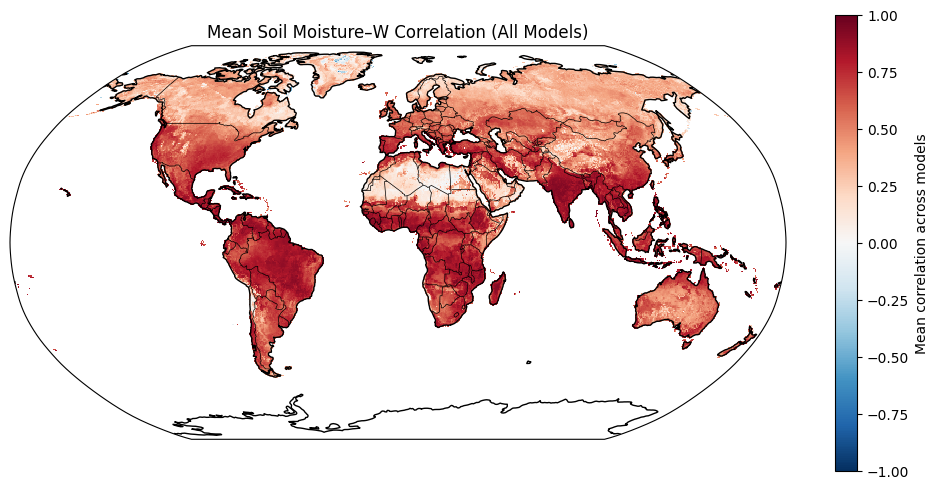

✅ 已保存均值文件： D:\smq\paper2\uncertainty\mean_model_soilmoist_w_corr.nc


In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import numpy as np
import os

# =========================================
# 1. 文件读取
# =========================================
folder = r"D:\smq\paper2\uncertainty\correlation_results"
files = sorted(glob.glob(os.path.join(folder, "*_soilmoist_w_corr.nc")))
print(f"共找到 {len(files)} 个文件")

datasets = []

for f in files:
    try:
        ds = xr.open_dataset(f, engine="h5netcdf")

        # 自动识别变量名
        var_name = list(ds.data_vars.keys())[0]
        da = ds[var_name]

        # --------- 维度标准化 ----------
        # 某些文件可能出现 ('lat','lat') 或 ('lon','lon') 的重复维度警告
        # 这里强制命名为 (lat, lon)
        if len(da.dims) == 2:
            da = da.rename({da.dims[0]: "lat", da.dims[1]: "lon"})
        elif "latitude" in da.dims:
            da = da.rename({"latitude": "lat"})
        elif "Longitude" in da.dims:
            da = da.rename({"Longitude": "lon"})

        # 强制 lat/lon 为坐标（防止某些文件 lat/lon 是变量）
        if "lat" not in da.coords and "lat" in ds.variables:
            da = da.assign_coords(lat=ds["lat"])
        if "lon" not in da.coords and "lon" in ds.variables:
            da = da.assign_coords(lon=ds["lon"])

        # 丢弃缺失坐标的文件
        if "lat" in da.coords and "lon" in da.coords:
            datasets.append(da)
        else:
            print(f"⚠️ {os.path.basename(f)} 缺失坐标，已跳过。")

    except Exception as e:
        print(f"❌ 读取 {f} 出错: {e}")

# =========================================
# 2. 拼接与求平均
# =========================================
if len(datasets) == 0:
    raise RuntimeError("没有成功读取任何可用数据，请检查文件内容。")

# 宽松拼接：允许 lat/lon 不完全一致
da_all = xr.concat(datasets, dim="model", join="outer", coords="minimal", compat="override")


# 求均值
da_mean = da_all.mean(dim="model", skipna=True)

# =========================================
# 3. 绘图
# =========================================
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Robinson())

im = da_mean.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    cbar_kwargs={"label": "Mean correlation across models"}
)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Mean Soil Moisture–W Correlation (All Models)", fontsize=12)
plt.tight_layout()
plt.show()

# =========================================
# 4. 保存结果
# =========================================
out_fp = os.path.join(r"D:\smq\paper2\uncertainty\mean_model_soilmoist_w_corr.nc")
da_mean.to_netcdf(out_fp)
print("✅ 已保存均值文件：", out_fp)


soil moisture (w monthavg vs era5)

In [7]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# ======================
# 1. 文件路径
# ======================
fp_soil = r"F:\smq\paper2\soilmoist\sm_root_0.5degree.nc"
fp_w    = r"F:\smq\paper2\w\w_monthavg.nc"
out_fp  = r"D:\smq\paper2\uncertainty\result\sm_era5_w_corr.nc"

# ======================
# 2. soilmoist 数据读取
# ======================
sm = xr.open_dataset(fp_soil, engine="h5netcdf")
sm_var = list(sm.data_vars)[0]
sm_da = sm[sm_var]

# ======================
# 3. w 数据读取（关闭时间解码）
# ======================
w_ds = xr.open_dataset(fp_w, engine="h5netcdf", decode_times=False)
w_var = list(w_ds.data_vars)[0]
w_da = w_ds[w_var]

# 构建时间轴
base_year = 1915
base_month = 1
new_time = pd.date_range(
    start=f"{base_year}-{base_month:02d}-01",
    periods=len(w_da.time),
    freq="MS"
)
w_da = w_da.assign_coords(time=new_time)

# ======================
# 4. 时间对齐
# ======================
common_time = np.intersect1d(sm_da["time"].values, w_da["time"].values)
sm_da = sm_da.sel(time=common_time)
w_da  = w_da.sel(time=common_time)

# 纬度经度方向一致化
if np.any(np.diff(sm_da.lat) < 0):
    sm_da = sm_da.sortby("lat")
if np.any(np.diff(sm_da.lon) < 0):
    sm_da = sm_da.sortby("lon")
if np.any(np.diff(w_da.lat) < 0):
    w_da = w_da.sortby("lat")
if np.any(np.diff(w_da.lon) < 0):
    w_da = w_da.sortby("lon")

# 插值到统一网格
if not sm_da.lat.equals(w_da.lat) or not sm_da.lon.equals(w_da.lon):
    sm_da = sm_da.interp(lat=w_da.lat, lon=w_da.lon)

# ======================
# 5. 逐格点计算 r、p、R²
# ======================
def corr_r_p_r2(x, y):
    """x, y 是一维时间序列，返回 r, p, R2"""
    # 如果全是 NaN，返回 NaN
    if np.all(np.isnan(x)) or np.all(np.isnan(y)):
        return np.nan, np.nan, np.nan
    r, p = pearsonr(x, y)
    r2 = r**2
    return r, p, r2

# 使用 apply_ufunc
result = xr.apply_ufunc(
    corr_r_p_r2,
    sm_da, w_da,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[[], [], []],
    vectorize=True,
    dask="parallelized",  # 如果使用 dask，可并行
    output_dtypes=[float, float, float],
)

r_da, p_da, r2_da = result

# 设置名字和属性
r_da.name = "r"
p_da.name = "p_value"
r2_da.name = "R2"

for da in [r_da, p_da, r2_da]:
    da.attrs["description"] = "Pixel-wise correlation metric between soil moisture and w"

# ======================
# 6. 保存到 NetCDF
# ======================
xr.merge([r_da, p_da, r2_da]).to_netcdf(out_fp, engine="h5netcdf")
print(f"✅ 已保存相关性结果: {out_fp}")


✅ 已保存相关性结果: D:\smq\paper2\uncertainty\result\sm_era5_w_corr.nc


C:\Users\DELL\AppData\Local\Temp\ipykernel_16504\3081673384.py:95: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  xr.merge([r_da, p_da, r2_da]).to_netcdf(out_fp, engine="h5netcdf")


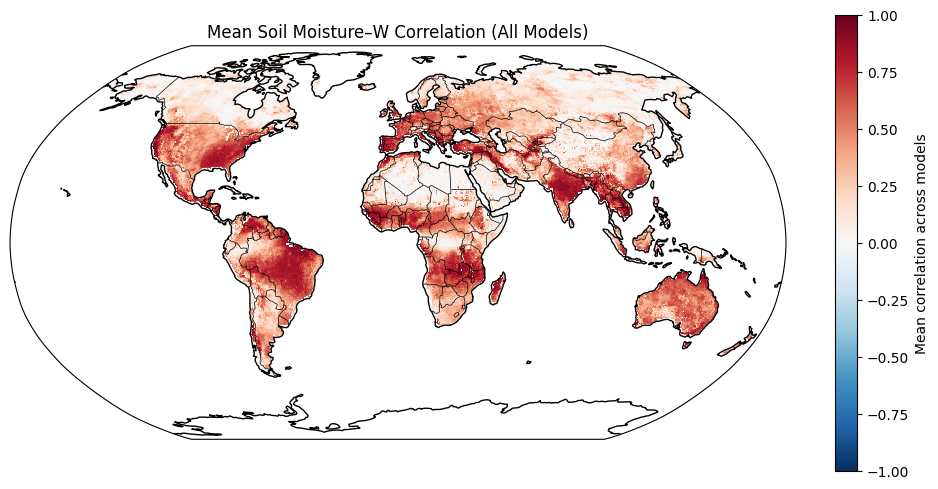

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Robinson())

r2_da=xr.open_dataset(r"D:\smq\paper2\uncertainty\result\sm_era5_w_corr.nc")['R2']
im = r2_da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    cbar_kwargs={"label": "Mean correlation across models"}
)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title("Mean Soil Moisture–W Correlation (All Models)", fontsize=12)
plt.tight_layout()
plt.show()

In [1]:
import xarray as xr
r2_da=xr.open_dataset(r"D:\smq\paper2\uncertainty\result\sm_era5_w_corr.nc")['R2']
r2_da.mean()

<xarray.DataArray 'R2' ()> Size: 8B
array(0.32160984)
Coordinates:
    number   int64 8B ...

sc-PDSI-monthly-daily mask

In [1]:
import xarray as xr
import numpy as np
from dask.distributed import Client, LocalCluster
import os
import dask

# ============================================================
# 1. 启动 Dask 集群（根据设备配置修改）
# ============================================================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=2,
    memory_limit="100GB"
)
client = Client(cluster)
print("✅ Dask dashboard:", client.dashboard_link)

# ============================================================
# 2. 参数设置
# ============================================================
min_days = 3          # 定义连续阈值
pdsi_thresh = -1      # 干旱阈值
start_date = "1920-01-01"
end_date = "2019-12-31"
out_fp = r"D:\smq\paper2\uncertainty\cdhw_mask_pdsi.nc"

# ============================================================
# 3. 数据读取
# ============================================================
print("📂 正在加载数据...")

# 热浪阈值 (tas95)
tas95 = (
    xr.open_dataset(
        r"E:\smq\tas95_1981_2010.nc",
        chunks={"lat": 30, "lon": 30}
    )["tas95"] - 273.15
)

# 日最高温 (tasmax)
tasmax = (
    xr.open_dataset(
        r"E:\smq\Tmax\TMax_daily.nc",
        engine="h5netcdf"
    )
    .sel(time=slice(start_date, end_date))
    .chunk({"time": -1, "lat": 30, "lon": 30})["TMax"]
)

# 月尺度 PDSI
pdsi = xr.open_dataset(
    r"D:\smq\paper2\uncertainty\scPDSI.cru_ts4.09early1.1901.2024.cal_1901_24.bams.2025.GLOBAL.IGBP.WHC.1901.2024.nc"
)

# 修正维度名
if "latitude" in pdsi.dims:
    pdsi = pdsi.rename({"latitude": "lat", "longitude": "lon"})

pdsi = pdsi['scpdsi'].sel(time=slice(start_date, end_date)).chunk({"time": -1, "lat": 30, "lon": 30})

print("✅ 数据加载完成：")
print(f"   - tas95: {tas95.shape}")
print(f"   - tasmax: {tasmax.shape}")
print(f"   - pdsi: {pdsi.shape}")

# ============================================================
# 4. 将月尺度 pdsi 转为日尺度
# ============================================================
print("🕒 将 PDSI 插值为日尺度...")
pdsi_daily = pdsi.resample(time="1D").ffill()

# ============================================================
# 5. 构建干旱与热浪标志
# ============================================================
print("🌡️ 构建热浪与干旱标志...")
drought_flag = pdsi_daily < pdsi_thresh
hot_flag = tasmax > tas95

# ============================================================
# 6. 连续事件检测函数
# ============================================================
def detect_events_1d(flag, min_days=3):
    """检测布尔序列中连续为 True 的事件"""
    mask = np.zeros_like(flag, dtype=bool)
    count = 0
    for i in range(len(flag)):
        if flag[i]:
            count += 1
        else:
            if count >= min_days:
                mask[i-count:i] = True
            count = 0
    if count >= min_days:
        mask[len(flag)-count:] = True
    return mask

# ============================================================
# 7. 并行热浪事件检测
# ============================================================
print("⚙️ 检测热浪事件（并行中）...")
hw_mask = xr.apply_ufunc(
    detect_events_1d,
    hot_flag,
    input_core_dims=[["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[bool],
    kwargs={"min_days": min_days},
)

# ============================================================
# 8. 构建 CDHW 掩膜
# ============================================================
print("🔥 计算 CDHW 掩膜...")
cdhw_mask = hw_mask & drought_flag

# ============================================================
# 9. 保存结果（安全写出，防止锁冲突）
# ============================================================
print("💾 正在计算并保存结果...")
cdhw_mask_local = cdhw_mask.compute()  # 先完成计算（避免 Dask 并行写锁）

ds_out = xr.Dataset({"cdhw_mask": cdhw_mask_local.astype(np.int8)})

if os.path.exists(out_fp):
    os.remove(out_fp)

comp = dict(zlib=True, complevel=4)
encoding = {"cdhw_mask": comp}

ds_out.to_netcdf(out_fp, engine="h5netcdf", encoding=encoding)
print("✅ 已成功保存 CDHW 掩膜：", out_fp)

# ============================================================
# 10. 关闭 Dask 集群
# ============================================================
client.close()
cluster.close()
print("🏁 全部流程完成！")


✅ Dask dashboard: http://127.0.0.1:8787/status
📂 正在加载数据...
✅ 数据加载完成：
   - tas95: (360, 720)
   - tasmax: (36525, 360, 720)
   - pdsi: (1200, 360, 720)
🕒 将 PDSI 插值为日尺度...
🌡️ 构建热浪与干旱标志...
⚙️ 检测热浪事件（并行中）...
🔥 计算 CDHW 掩膜...
💾 正在计算并保存结果...
✅ 已成功保存 CDHW 掩膜： D:\smq\paper2\uncertainty\cdhw_mask_pdsi.nc
🏁 全部流程完成！


In [1]:
import xarray as xr
import numpy as np
from dask.distributed import Client, LocalCluster, performance_report
import dask
import os
import time

# ======================
# 配置 Dask
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="100GB"
)
client = Client(cluster)
print("✅ Dashboard 地址:", client.dashboard_link)

# ======================
# 参数
# ======================
start_date, end_date = "1920-01-01", "2019-12-31"

# ======================
# 打开数据
# ======================
print("⏳ [1] 读取温度分位数据...")
tas25 = xr.open_dataset(r"D:\smq\paper2\data\tas25_1981_2010.nc")["tas25"] - 273.15
tas75 = xr.open_dataset(r"D:\smq\paper2\data\tas75_1981_2010.nc")["tas75"] - 273.15
tas95 = xr.open_dataset(r"E:\smq\tas95_1981_2010.nc")["tas95"] - 273.15

print("⏳ [2] 打开每日 Tmax 数据...")
tasmax = xr.open_dataset(
    r"E:\smq\Tmax\TMax_daily.nc", engine="h5netcdf"
).sel(time=slice(start_date, end_date)).chunk({"time": -1, "lat": 50, "lon": 50})["TMax"]

print("⏳ [3] 打开月尺度 scPDSI 数据...")
pdsi = xr.open_dataset(
    r"D:\smq\paper2\uncertainty\scPDSI.cru_ts4.09early1.1901.2024.cal_1901_24.bams.2025.GLOBAL.IGBP.WHC.1901.2024.nc"
)
if "latitude" in pdsi.dims:
    pdsi = pdsi.rename({"latitude": "lat", "longitude": "lon"})
pdsi = pdsi['scpdsi'].sel(time=slice(start_date, end_date)).chunk({"time": -1, "lat": 50, "lon": 50})

print("✅ [4] 转为日尺度...")
t0 = time.time()
scpdsi_daily = pdsi.resample(time="1D").ffill()
print(f"✅ 完成月→日插值 ({time.time()-t0:.2f}s)")

print("⏳ [5] 读取 CDHW 掩膜...")
cdhw_mask = xr.open_dataset(
    r"D:\smq\paper2\uncertainty\cdhw_mask_pdsi.nc", engine="h5netcdf"
)["cdhw_mask"].sel(time=slice(start_date, end_date)).chunk({"time": -1, "lat": 50, "lon": 50})

# 统一 chunk，防止 rechunk 卡顿
print("⏳ [6] 统一 chunk 大小...")
scpdsi_daily = scpdsi_daily.chunk({"time": -1, "lat": 50, "lon": 50})

print("⏳ [7] 构建 daily_severity 任务图...")
t0 = time.time()
daily_severity = xr.where(
    cdhw_mask,
    np.abs(scpdsi_daily) * (tasmax - tas25) / (tas75 - tas25),
    0
)
print(f"✅ daily_severity 构建完成 ({time.time()-t0:.2f}s)")
print(daily_severity)

# ======================
# 保存输出
# ======================
output_file = r"D:\smq\paper2\uncertainty\cdhw_daily_severity_pdsi.nc"
encoding = {"daily_severity": {"zlib": True, "complevel": 4, "dtype": "float32"}}

if os.path.exists(output_file):
    os.remove(output_file)

ds_out = xr.Dataset({"daily_severity": daily_severity})
delayed_obj = ds_out.to_netcdf(
    output_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=False
)


ERROR! Session/line number was not unique in database. History logging moved to new session 818


C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 57620 instead
  warnings.warn(


✅ Dashboard 地址: http://127.0.0.1:57620/status
⏳ [1] 读取温度分位数据...
⏳ [2] 打开每日 Tmax 数据...
⏳ [3] 打开月尺度 scPDSI 数据...
✅ [4] 转为日尺度...
✅ 完成月→日插值 (0.04s)
⏳ [5] 读取 CDHW 掩膜...
⏳ [6] 统一 chunk 大小...
⏳ [7] 构建 daily_severity 任务图...
✅ daily_severity 构建完成 (0.04s)
<xarray.DataArray (lat: 360, lon: 720, time: 36495)> Size: 76GB
dask.array<where, shape=(360, 720, 36495), dtype=float64, chunksize=(50, 50, 36495), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float64 3kB 89.75 89.25 88.75 88.25 ... -88.75 -89.25 -89.75
  * time     (time) datetime64[ns] 292kB 1920-01-01 1920-01-02 ... 2019-12-01
🚀 [8] 开始 Dask 分布式写出任务...
✅ [9] 写出成功: D:\smq\paper2\uncertainty\cdhw_daily_severity_pdsi.nc
📊 性能报告保存在: Dask_report.html

📋 Dask 诊断信息：
<Client: 'tcp://127.0.0.1:57625' processes=10 threads=10, memory=0.91 TiB>
活跃 workers: 5


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from dask.distributed import Client, LocalCluster
import os
import dask  # 提前导入dask，避免后续计算时导入延迟

# ======================
# 配置 Dask
# ======================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=1,
    memory_limit="100GB"
)
client = Client(cluster)
print("Dashboard 地址:", client.dashboard_link)

# ======================
# 读数据（修复分块警告）
# ======================
mask_fp = r"D:\smq\paper2\data\cdhw\masks_cdhw_hw_di.nc"
ds_mask = xr.open_dataset(
    mask_fp,
    engine="h5netcdf"
).chunk({"time": -1, "lat": 50, "lon": 50})
cdhw_mask = ds_mask["cdhw_mask"]

severity_fp = r"D:\smq\paper2\uncertainty\cdhw_daily_severity_pdsi.nc"
ds_sev = xr.open_dataset(
    severity_fp,
    engine="h5netcdf"
).chunk({"time": -1, "lat": 50, "lon": 50})
daily_severity = ds_sev["daily_severity"]

def process_point_intensity(mask_1d, time_vals):

    # 转换时间为 pandas DatetimeIndex
    times = pd.to_datetime(time_vals)

    # 定义年份范围
    years_all = np.arange(times[0].year, times[-1].year + 1)
    c = np.zeros(len(years_all), dtype=np.float32)  # 存储每年的结果

    # Step1: 提取事件（连续非零天为一个事件）
    in_event = False
    event_id = np.zeros(len(mask_1d), dtype=int)
    eid = 0

    for i, val in enumerate(mask_1d):
        if val > 0 and not in_event:
            eid += 1
            in_event = True
        elif val == 0:
            in_event = False
        if in_event:
            event_id[i] = eid

    # Step2: 遍历每个事件，计算其平均强度，并记录起始年份
    yearly_intensities = {year: [] for year in years_all}  # 每年收集事件的平均强度

    for e in np.unique(event_id):
        if e == 0:
            continue  # 跳过无事件区域

        indices = np.where(event_id == e)[0]
        start_idx = indices[0]
        event_values = mask_1d[indices]

        avg_intensity = np.mean(event_values)  # 该事件的平均强度
        year = times[start_idx].year

        if year in yearly_intensities:
            yearly_intensities[year].append(avg_intensity)

    # Step3: 对每一年，取该年所有事件平均强度的平均值
    for i, year in enumerate(years_all):
        intensities = yearly_intensities[year]
        if len(intensities) > 0:
            c[i] = np.mean(intensities)  # 可改为 np.sum 如果需要总和
        else:
            c[i] = 0.0  # 无事件则为0

    return c  # shape=(nyears,)
# ======================
# 计算完整年份范围（用于输出维度）
# ======================
years_all = np.arange(
    int(cdhw_mask.time.dt.year.min()),
    int(cdhw_mask.time.dt.year.max()) + 1
)

# ======================
# 并行调用函数
# ======================
annual_strength = xr.apply_ufunc(
    process_point_intensity,
    daily_severity,
    input_core_dims=[["time"]],
    output_core_dims=[["year"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float32],
    dask_gufunc_kwargs={"output_sizes": {"year": len(years_all)}},
    kwargs={"time_vals": daily_severity.time.values},
)


annual_strength = annual_strength.assign_coords(year=years_all)
annual_strength.name = "annual_severity"

# ======================
# 创建Dataset
# ======================
ds_out = xr.Dataset(
    data_vars={"annual_severity": annual_strength},
    coords={
        "year": years_all,
        "lat": cdhw_mask.lat,
        "lon": cdhw_mask.lon
    }
)

# ======================
# 保存结果
# ======================
output_file = r"D:\smq\paper2\uncertainty\cdhw_meanevent_yearly_severity.nc"
encoding = {
    "annual_severity": {"zlib": True, "complevel": 4, "dtype": "float32"}
}

if os.path.exists(output_file):
    os.remove(output_file)

print("保存结果...")
delayed = ds_out.to_netcdf(
    output_file,
    engine="h5netcdf",
    encoding=encoding,
    compute=False
)
dask.compute(delayed)

print(f"[Success] 文件已写入: {output_file}")
client.close()


Dashboard 地址: http://127.0.0.1:8787/status
保存结果...
[Success] 文件已写入: D:\smq\paper2\uncertainty\cdhw_meanevent_yearly_severity.nc


spei-monthly-daily mask

In [1]:
import xarray as xr
import numpy as np
from dask.distributed import Client, LocalCluster
import os
import dask

# ============================================================
# 1. 启动 Dask 集群（根据设备配置修改）
# ============================================================
cluster = LocalCluster(
    n_workers=10,
    threads_per_worker=2,
    memory_limit="100GB"
)
client = Client(cluster)
print("✅ Dask dashboard:", client.dashboard_link)

# ============================================================
# 2. 参数设置
# ============================================================
min_days = 3          # 定义连续阈值
pdsi_thresh = -1      # 干旱阈值
start_date = "1920-01-01"
end_date = "2019-12-31"
out_fp = r"D:\smq\paper2\uncertainty\cdhw_mask_spei.nc"

# ============================================================
# 3. 数据读取
# ============================================================
print("📂 正在加载数据...")

# 热浪阈值 (tas95)
tas95 = (
    xr.open_dataset(
        r"E:\smq\tas95_1981_2010.nc",
        chunks={"lat": 30, "lon": 30}
    )["tas95"] - 273.15
)

# 日最高温 (tasmax)
tasmax = (
    xr.open_dataset(
        r"E:\smq\Tmax\TMax_daily.nc",
        engine="h5netcdf"
    )
    .sel(time=slice(start_date, end_date))
    .chunk({"time": -1, "lat": 30, "lon": 30})["TMax"]
)

# 月尺度 PDSI
pdsi = xr.open_dataset(
    r"D:\smq\paper2\uncertainty\monthly_spei.nc"
)

# 修正维度名
pdsi = pdsi['spei'].sel(time=slice(start_date, end_date)).chunk({"time": -1, "lat": 30, "lon": 30})

print("✅ 数据加载完成：")
print(f"   - tas95: {tas95.shape}")
print(f"   - tasmax: {tasmax.shape}")
print(f"   - pdsi: {pdsi.shape}")

# ============================================================
# 4. 将月尺度 pdsi 转为日尺度
# ============================================================
print("🕒 将 PDSI 插值为日尺度...")
pdsi_daily = pdsi.resample(time="1D").ffill()

# ============================================================
# 5. 构建干旱与热浪标志
# ============================================================
print("🌡️ 构建热浪与干旱标志...")
drought_flag = pdsi_daily < pdsi_thresh
hot_flag = tasmax > tas95

# ============================================================
# 6. 连续事件检测函数
# ============================================================
def detect_events_1d(flag, min_days=3):
    """检测布尔序列中连续为 True 的事件"""
    mask = np.zeros_like(flag, dtype=bool)
    count = 0
    for i in range(len(flag)):
        if flag[i]:
            count += 1
        else:
            if count >= min_days:
                mask[i-count:i] = True
            count = 0
    if count >= min_days:
        mask[len(flag)-count:] = True
    return mask

# ============================================================
# 7. 并行热浪事件检测
# ============================================================
print("⚙️ 检测热浪事件（并行中）...")
hw_mask = xr.apply_ufunc(
    detect_events_1d,
    hot_flag,
    input_core_dims=[["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[bool],
    kwargs={"min_days": min_days},
)

# ============================================================
# 8. 构建 CDHW 掩膜
# ============================================================
print("🔥 计算 CDHW 掩膜...")
cdhw_mask = hw_mask & drought_flag

# ============================================================
# 9. 保存结果（安全写出，防止锁冲突）
# ============================================================
print("💾 正在计算并保存结果...")
cdhw_mask_local = cdhw_mask.compute()  # 先完成计算（避免 Dask 并行写锁）

ds_out = xr.Dataset({"cdhw_mask": cdhw_mask_local.astype(np.int8)})

if os.path.exists(out_fp):
    os.remove(out_fp)

comp = dict(zlib=True, complevel=4)
encoding = {"cdhw_mask": comp}

ds_out.to_netcdf(out_fp, engine="h5netcdf", encoding=encoding)
print("✅ 已成功保存 CDHW 掩膜：", out_fp)

# ============================================================
# 10. 关闭 Dask 集群
# ============================================================
client.close()
cluster.close()
print("🏁 全部流程完成！")


✅ Dask dashboard: http://127.0.0.1:8787/status
📂 正在加载数据...
✅ 数据加载完成：
   - tas95: (360, 720)
   - tasmax: (36525, 360, 720)
   - pdsi: (360, 720, 1200)
🕒 将 PDSI 插值为日尺度...
🌡️ 构建热浪与干旱标志...
⚙️ 检测热浪事件（并行中）...
🔥 计算 CDHW 掩膜...
💾 正在计算并保存结果...
✅ 已成功保存 CDHW 掩膜： D:\smq\paper2\uncertainty\cdhw_mask_spei.nc
🏁 全部流程完成！


spei-scpdsi cdhw mask r/r2

In [1]:
# -*- coding: utf-8 -*-
import xarray as xr
import numpy as np
from scipy.stats import linregress

# ====================
# 路径设置
# ====================
file_spei = r"D:\smq\paper2\uncertainty\cdhw_mask_spei.nc"
file_pdsi = r"D:\smq\paper2\uncertainty\cdhw_mask_pdsi.nc"
out_file  = r"D:\smq\paper2\uncertainty\result\spei-pdsi_cdhw_mask_corr.nc"
mask = xr.open_dataset(r"D:\smq\paper2\data\modified_mask.nc").mask_data
mask = mask > 1

# ====================
# 读取数据
# ====================
ds_spei = xr.open_dataset(file_spei)
ds_pdsi = xr.open_dataset(file_pdsi)

var_spei = list(ds_spei.data_vars)[0]
var_pdsi = list(ds_pdsi.data_vars)[0]

da_spei = ds_spei[var_spei]
da_pdsi = ds_pdsi[var_pdsi]

# ====================
# 年聚合（按年份求和或平均）
# ====================
da_spei_yearly = da_spei.groupby('time.year').mean()
da_pdsi_yearly = da_pdsi.groupby('time.year').mean()

# ====================
# 定义逐格点函数
# ====================
def corr_func(x, y):
    """返回 r, p, r²"""
    mask_valid = np.isfinite(x) & np.isfinite(y)
    x = x[mask_valid]
    y = y[mask_valid]
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan, np.nan
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    return r_value, p_value, r_value ** 2

# ====================
# 逐格点并行计算
# ====================
res = xr.apply_ufunc(
    corr_func,
    da_spei_yearly,
    da_pdsi_yearly,
    input_core_dims=[["year"], ["year"]],
    output_core_dims=[[], [], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float, float],
)

r, p, r2 = res

# ====================
# 构建输出 Dataset
# ====================
ds_out = xr.Dataset(
    {
        "r": (("lat", "lon"), r.where(mask).data),
        "p_value": (("lat", "lon"), p.where(mask).data),
        "R2": (("lat", "lon"), r2.where(mask).data),
    },
    coords={
        "lat": r.lat,
        "lon": r.lon,
    }
)


# ====================
# 保存结果
# ====================
ds_out.to_netcdf(out_file)
print(f"✅ 已保存空间相关结果，包括 r, p, r² 到: {out_file}")


✅ 已保存空间相关结果，包括 r, p, r² 到: D:\smq\paper2\uncertainty\result\spei-pdsi_cdhw_mask_corr.nc


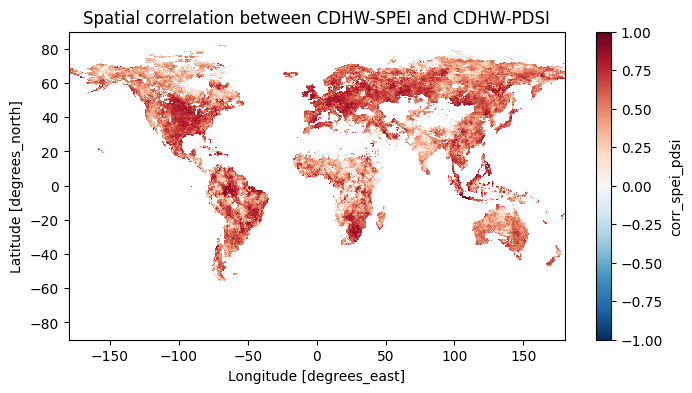

In [20]:
# ====================
# 可视化（可选）
# ====================
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
r.plot(cmap='RdBu_r', vmin=-1, vmax=1)
plt.title("Spatial correlation between CDHW-SPEI and CDHW-PDSI")
plt.show()

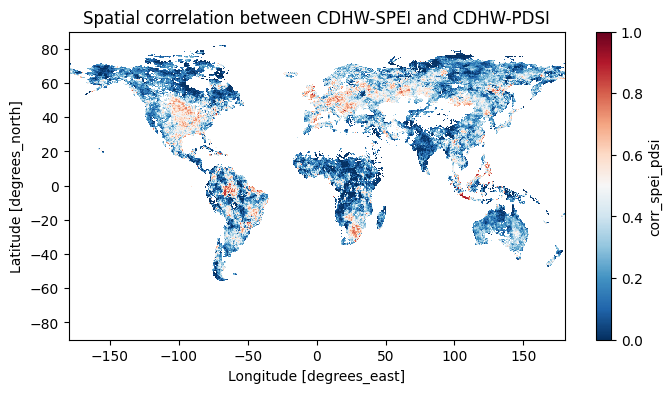

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
(corr**2).plot(cmap='RdBu_r', vmin=0, vmax=1)
plt.title("Spatial correlation between CDHW-SPEI and CDHW-PDSI")
plt.show()

In [2]:
import xarray as xr
r2_da=xr.open_dataset(r"D:\smq\paper2\uncertainty\result\spei-pdsi_cdhw_mask_corr.nc")['R2']
r2_da.mean()

<xarray.DataArray 'R2' ()> Size: 8B
array(0.280912)
Coordinates:
    quantile  float64 8B ...

### sm point

In [ ]:
import os
import pandas as pd
import xarray as xr
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from tqdm import tqdm  # 可选，用于显示进度

# -----------------------------
# 1. ISMN 数据根目录
# -----------------------------
root_dir = r"F:\smq\paper2\soilmoist\ismn\Data_separate_files_header_19500101_20191231_12896_nFVG_20251215 (1)"

# -----------------------------
# 2. 读取模型土壤水数据
# -----------------------------
ds_w = xr.open_dataset(r"F:\smq\paper2\w\w_daily.nc")
w_time = pd.to_datetime(ds_w["time"].values)
w_lat = ds_w["lat"].values
w_lon = ds_w["lon"].values

# -----------------------------
# 3. 循环每个网络/站点
# -----------------------------
results = []

networks = [n for n in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, n))]

for network in networks:
    network_dir = os.path.join(root_dir, network)
    stations = [s for s in os.listdir(network_dir) if os.path.isdir(os.path.join(network_dir, s))]

    for station in tqdm(stations, desc=f"Processing {network}"):
        sta_dir = os.path.join(network_dir, station)
        stm_files = [f for f in os.listdir(sta_dir) if f.endswith(".stm")]

        records = []
        lat = lon = None

        for stm_file in stm_files:
            stm_path = os.path.join(sta_dir, stm_file)
            try:
                with open(stm_path, "r") as f:
                    lines = f.readlines()
                    if len(lines) < 2:
                        continue

                    # 头信息
                    header = lines[0].strip().split()
                    if len(header) < 8:
                        continue

                    if lat is None:  # 取第一个文件的 lat/lon
                        lat = float(header[3])
                        lon = float(header[4])

                    # 数据记录
                    for line in lines[1:]:
                        parts = line.strip().split()
                        if len(parts) < 4:
                            continue
                        date = parts[0] + " " + parts[1]
                        value = parts[2]
                        try:
                            value = float(value)
                        except:
                            value = None
                        records.append({"datetime": date, "value": value})
            except Exception as e:
                print(f"FAILED: {stm_path}\n{e}")

        if not records or lat is None:
            continue  # 无数据跳过

        # 转为 DataFrame 并按天聚合
        df_sta = pd.DataFrame(records)
        df_sta["datetime"] = pd.to_datetime(df_sta["datetime"])
        df_sta["date"] = df_sta["datetime"].dt.date
        df_sta_daily = df_sta.groupby("date")["value"].mean().reset_index()

        # 剔除不足一年的点
        if len(df_sta_daily) < 365:
            continue

        # 提取最近网格点
        w_sel = ds_w.sel(lat=lat, lon=lon, method="nearest")["w"]
        df_w = pd.DataFrame({
            "date": w_time.date,
            "w_value": w_sel.values
        })

        # 合并并筛选有效值
        df_merge = pd.merge(df_sta_daily, df_w, on="date", how="inner")
        valid = df_merge["value"].notna() & df_merge["w_value"].notna()
        if valid.sum() < 365:
            continue

        x = df_merge.loc[valid, "value"]
        y = df_merge.loc[valid, "w_value"]

        r, p_value = pearsonr(x, y)
        r2 = r2_score(x, y)

        results.append({
            "network": network,
            "station": station,
            "lat": lat,
            "lon": lon,
            "r": r,
            "r2": r2,
            "p_value": p_value,
            "n_samples": valid.sum()
        })

# -----------------------------
# 4. 保存结果
# -----------------------------
df_results = pd.DataFrame(results)
df_results.to_csv(r"F:\smq\paper2\ismn_vs_model_r_results.csv", index=False)
print("完成！共有站点:", len(df_results))
print(df_results.head())
